# Customer Churn Analysis for Retention Insights

This notebook addresses two complementary objectives:
- **Exercise 1**: Exploratory analysis and insight generation to better understand customer retention.
- **Exercise 2**: Predictive modelling to estimate churn risk and support proactive intervention.

The goal is not only to build a useful predictive model, but also to surface clear, practical insights
that can help the Head of Family Experience and the operations team make more data-driven decisions.

## 1. Business Objective and Challenge Framing

This analysis is designed to better understand why customers leave, move beyond anecdotal explanations,
and use historical data to improve retention.

This notebook is structured around two linked questions:

1. **What patterns in the data help explain customer churn and retention?**
2. **Can we build a predictive model that identifies likely churners and highlights useful areas for intervention?**

In [1]:
import os
import warnings
from pathlib import Path
from typing import Any, Dict

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-cache")

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from IPython import get_ipython
from IPython.display import Markdown, display
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import (
    GradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
np.random.seed(42)

PALETTE = {"no_churn": "#4F46E5", "churn": "#D946EF"}
COLORS = [PALETTE["no_churn"], PALETTE["churn"]]
ACCENTS = ["#7C3AED", "#6366F1", "#3B82F6", "#14B8A6", "#8B5CF6", "#EC4899"]
THEME_COLORS = ["#7C3AED", "#6366F1", "#3B82F6", "#06B6D4", "#10B981", "#EC4899", "#F59E0B"]
BG = "#FCFBFF"
GRID_CLR = "#E8E2F3"
CORR_CMAP = sns.diverging_palette(285, 160, s=80, l=55, as_cmap=True)
SEQUENTIAL_CMAP = sns.blend_palette(["#F5EEFF", "#8B5CF6", "#3B82F6", "#14B8A6"], as_cmap=True)
CONFUSION_CMAP = sns.blend_palette(["#EEF2FF", "#818CF8", "#7C3AED"], as_cmap=True)

sns.set_theme(style="whitegrid", palette=THEME_COLORS, font="DejaVu Sans")
plt.rcParams.update(
    {
        "figure.facecolor": BG,
        "axes.facecolor": BG,
        "axes.edgecolor": GRID_CLR,
        "grid.color": GRID_CLR,
        "grid.linewidth": 0.6,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titlesize": 13,
        "axes.titleweight": "bold",
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
        "figure.dpi": 120,
    }
)


# =============================================================================
# Lightweight notebook helpers only
# =============================================================================

def ensure_output_dirs() -> None:
    os.makedirs("images", exist_ok=True)


def configure_notebook_display() -> None:
    ip = get_ipython()
    if ip is not None:
        try:
            ip.run_line_magic("matplotlib", "inline")
        except Exception:
            pass


def section_title(title: str) -> None:
    line = "=" * 88
    print(f"\n{line}\n{title.upper()}\n{line}")


def subsection_title(title: str) -> None:
    print(f"\n{title}\n" + "-" * len(title))


def metric_block(title: str, metrics: Dict[str, Any]) -> None:
    print(f"\n{title}")
    print("-" * len(title))
    for key, value in metrics.items():
        if isinstance(value, float):
            print(f"{key:<28}: {value:.4f}")
        else:
            print(f"{key:<28}: {value}")


def display_shape_summary(data: pd.DataFrame, name: str = "Dataset") -> None:
    print(f"{name}: {data.shape[0]:,} rows, {data.shape[1]:,} columns")


def display_missing_summary(data: pd.DataFrame, top_n: int = 15) -> pd.DataFrame:
    summary = (
        data.isnull()
        .sum()
        .rename("missing_count")
        .to_frame()
        .assign(missing_pct=lambda x: x["missing_count"] / len(data))
        .sort_values(["missing_count", "missing_pct"], ascending=False)
        .head(top_n)
    )
    print("\nTop Missingness Summary")
    print(summary)
    return summary


def display_target_summary(data: pd.DataFrame, target_col: str) -> pd.DataFrame:
    summary = (
        data[target_col]
        .value_counts(dropna=False)
        .rename_axis(target_col)
        .reset_index(name="count")
    )
    summary["pct"] = summary["count"] / summary["count"].sum()
    print(f"\nTarget Summary: {target_col}")
    print(summary)
    return summary


def style_ax(ax, title=None, xlabel=None, ylabel=None):
    if title:
        ax.set_title(title, pad=10)
    if xlabel:
        ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)
    ax.tick_params(length=0)


def build_palette(n: int, palette_name: str | None = None):
    if palette_name is None:
        return sns.color_palette(THEME_COLORS, n_colors=max(1, n))
    return sns.color_palette(palette_name, n_colors=max(1, n))


def plot_triangular_correlation_heatmap(
    data: pd.DataFrame,
    columns,
    title: str,
    cmap=CORR_CMAP,
) -> None:
    corr = data[columns].corr(numeric_only=True)
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

    fig, ax = plt.subplots(figsize=(10, 7))
    sns.heatmap(
        corr,
        mask=mask,
        cmap=cmap,
        center=0,
        annot=True,
        fmt=".2f",
        linewidths=0.8,
        linecolor="white",
        cbar_kws={"shrink": 0.85},
        square=True,
        ax=ax,
    )
    style_ax(ax, title, "", "")
    plt.tight_layout()
    plt.show()


ensure_output_dirs()
configure_notebook_display()

In [2]:
section_title("Load Data")

data_path = Path("data") / "churn.csv"

if not data_path.exists():
    raise FileNotFoundError(f"Could not find dataset: {data_path.resolve()}")

df = pd.read_csv(data_path)

display_shape_summary(df, "Raw dataset")
print("\nPreview:")
display(df.head())


LOAD DATA
Raw dataset: 36,992 rows, 24 columns

Preview:


,Unnamed: 0,age,gender,security_no,region_category,membership_category,joining_date,joined_through_referral,referral_id,preferred_offer_types,medium_of_operation,internet_option,last_visit_time,days_since_last_login,avg_time_spent,avg_transaction_value,avg_frequency_login_days,points_in_wallet,used_special_discount,offer_application_preference,past_complaint,complaint_status,feedback,churn_risk_score
0,0,18,F,XW0DQ7H,Village,Platinum Membership,2017-08-17,No,xxxxxxxx,Gift Vouchers/Coupons,?,Wi-Fi,16:08:02,17,300.63,53005.25,17.0,781.75,Yes,Yes,No,Not Applicable,Products always in Stock,0
1,1,32,F,5K0N3X1,City,Premium Membership,2017-08-28,?,CID21329,Gift Vouchers/Coupons,Desktop,Mobile_Data,12:38:13,16,306.34,12838.38,10.0,NaN,Yes,No,Yes,Solved,Quality Customer Care,0
2,2,44,F,1F2TCL3,Town,No Membership,2016-11-11,Yes,CID12313,Gift Vouchers/Coupons,Desktop,Wi-Fi,22:53:21,14,516.16,21027.00,22.0,500.69,No,Yes,Yes,Solved in Follow-up,Poor Website,1
3,3,37,M,VJGJ33N,City,No Membership,2016-10-29,Yes,CID3793,Gift Vouchers/Coupons,Desktop,Mobile_Data,15:57:50,11,53.27,25239.56,6.0,567.66,No,Yes,Yes,Unsolved,Poor Website,1
4,4,31,F,SVZXCWB,City,No Membership,2017-09-12,No,xxxxxxxx,Credit/Debit Card Offers,Smartphone,Mobile_Data,15:46:44,20,113.13,24483.66,16.0,663.06,No,Yes,Yes,Solved,Poor Website,1


## 2. Exercise 1, Exploratory Analysis and Business Insights

### 2.1 Data Quality Review

The first step is to clean missing placeholders and invalid values so the analysis and modelling
use more reliable data.

In [3]:
section_title("Exercise 1 - Data Quality Review")

df_clean = df.copy()
df_clean.columns = [c.strip() for c in df_clean.columns]

placeholder_values = ["?", "Unknown", "unknown", "NA", "N/A", ""]
object_cols = df_clean.select_dtypes(include="object").columns
df_clean[object_cols] = df_clean[object_cols].replace(placeholder_values, np.nan)

if "referral_id" in df_clean.columns:
    df_clean["referral_id"] = df_clean["referral_id"].replace(r"^x+$", np.nan, regex=True)

numeric_cols = [
    "age",
    "days_since_last_login",
    "avg_time_spent",
    "avg_transaction_value",
    "avg_frequency_login_days",
    "points_in_wallet",
]

if "avg_frequency_login_days" in df_clean.columns:
    df_clean["avg_frequency_login_days"] = df_clean["avg_frequency_login_days"].replace("Error", np.nan)

for col in numeric_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

df_clean["days_since_last_login"] = df_clean["days_since_last_login"].replace(-999, np.nan)

invalid_specs = {
    "age": "age_invalid",
    "days_since_last_login": "days_since_last_login_invalid",
    "avg_time_spent": "avg_time_spent_invalid",
    "avg_transaction_value": "avg_transaction_value_invalid",
    "avg_frequency_login_days": "avg_frequency_login_days_invalid",
    "points_in_wallet": "points_in_wallet_invalid",
}

for source_col, flag_col in invalid_specs.items():
    df_clean[flag_col] = df_clean[source_col].lt(0).astype(int)
    df_clean.loc[df_clean[source_col] < 0, source_col] = np.nan

df_clean["complaint_status"] = df_clean["complaint_status"].fillna("Missing")
df_clean["feedback"] = df_clean["feedback"].fillna("Missing")

display_shape_summary(df_clean, "Cleaned dataset")
missing_summary = display_missing_summary(df_clean, top_n=15)

print("\nInvalid Negative Value Checks")
invalid_value_summary = pd.Series(
    {flag_col: int(df_clean[flag_col].sum()) for flag_col in invalid_specs.values()},
    name="invalid_count",
).to_frame()
display(invalid_value_summary)

print("\nNumeric Feature Summary After Cleaning:")
display(df_clean[numeric_cols].describe().T)

print("\nData types after cleaning:")
display(df_clean.dtypes.to_frame("dtype"))

print(
    "\nOutlier handling note: no broad outlier removal is applied in this workflow. "
    "Potentially extreme values are retained unless they are clearly invalid placeholders "
    "or impossible negatives. This keeps the analysis closer to the original operational data "
    "while avoiding risky late-stage filtering decisions."
)


EXERCISE 1 - DATA QUALITY REVIEW
Cleaned dataset: 36,992 rows, 30 columns

Top Missingness Summary
                          missing_count  missing_pct
referral_id                       17846     0.482429
joined_through_referral            5438     0.147005
region_category                    5428     0.146734
medium_of_operation                5393     0.145788
avg_frequency_login_days           4205     0.113673
points_in_wallet                   3579     0.096751
days_since_last_login              1999     0.054039
avg_time_spent                     1719     0.046470
preferred_offer_types               288     0.007785
gender                               59     0.001595
Unnamed: 0                            0     0.000000
age                                   0     0.000000
security_no                           0     0.000000
membership_category                   0     0.000000
joining_date                          0     0.000000

Invalid Negative Value Checks


,invalid_count
age_invalid,0
days_since_last_login_invalid,0
avg_time_spent_invalid,1719
avg_transaction_value_invalid,0
avg_frequency_login_days_invalid,683
points_in_wallet_invalid,136



Numeric Feature Summary After Cleaning:


,count,mean,std,min,25%,50%,75%,max
age,36992.0,37.118161,15.867412,10.000000,23.00,37.000,51.00,64.000000
days_since_last_login,34993.0,12.758552,5.572600,1.000000,9.00,13.000,17.00,26.000000
avg_time_spent,35273.0,292.751466,331.946382,1.837399,71.56,174.180,371.16,3235.578521
avg_transaction_value,36992.0,29271.194003,19444.806226,800.460000,14177.54,27554.485,40855.11,99914.050000
avg_frequency_login_days,32787.0,16.538615,8.383666,0.009208,10.00,16.000,23.00,73.061995
points_in_wallet,33413.0,690.354685,186.426973,6.432208,617.26,698.250,764.26,2069.069761



Data types after cleaning:


,dtype
Unnamed: 0,int64
age,float64
gender,object
security_no,object
region_category,object
membership_category,object
joining_date,object
joined_through_referral,object
referral_id,object
preferred_offer_types,object



Outlier handling note: no broad outlier removal is applied in this workflow. Potentially extreme values are retained unless they are clearly invalid placeholders or impossible negatives. This keeps the analysis closer to the original operational data while avoiding risky late-stage filtering decisions.


### Optional automated profiling export

In [4]:
try:
    from ydata_profiling import ProfileReport

    section_title("Automated EDA Profiling")

    profile = ProfileReport(
        df_clean,
        title="Customer Churn, Cleaned Data Profiling Report",
        explorative=True,
        minimal=False,
    )
    profile.to_file("churn_eda_report.html")
    print("EDA report saved to churn_eda_report.html")

except Exception as e:
    print(f"ydata-profiling could not run: {e}")


AUTOMATED EDA PROFILING


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 30/30 [00:06<00:00,  4.56it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

EDA report saved to churn_eda_report.html


### 2.2 Data Structure and Initial Checks

In [5]:
id_columns = ["Unnamed: 0", "security_no", "referral_id"]
date_columns = ["joining_date", "last_visit_time"]
target = "churn_risk_score"

base_categorical_columns = [
    "gender",
    "region_category",
    "membership_category",
    "joined_through_referral",
    "preferred_offer_types",
    "medium_of_operation",
    "internet_option",
    "used_special_discount",
    "offer_application_preference",
    "feedback",
    "past_complaint",
    "complaint_status",
]

metric_block(
    "Column Categorization",
    {
        "ID columns": len(id_columns),
        "Date columns": len(date_columns),
        "Categorical columns": len(base_categorical_columns),
        "Numerical columns": len(numeric_cols),
        "Target variable": target,
    },
)

print(f"\nDuplicate rows after cleaning: {df_clean.duplicated().sum()}")

target_summary = display_target_summary(df_clean, target)
print(f"\nOverall churn rate: {df_clean[target].mean():.2%}")
print("\nThe supplied dataset contains a binary target column, so the task is treated as binary classification.")


Column Categorization
---------------------
ID columns                  : 3
Date columns                : 2
Categorical columns         : 12
Numerical columns           : 6
Target variable             : churn_risk_score

Duplicate rows after cleaning: 0

Target Summary: churn_risk_score
   churn_risk_score  count       pct
0                 1  20012  0.540982
1                 0  16980  0.459018

Overall churn rate: 54.10%

The supplied dataset contains a binary target column, so the task is treated as binary classification.


### 2.3 Initial Visual Profile

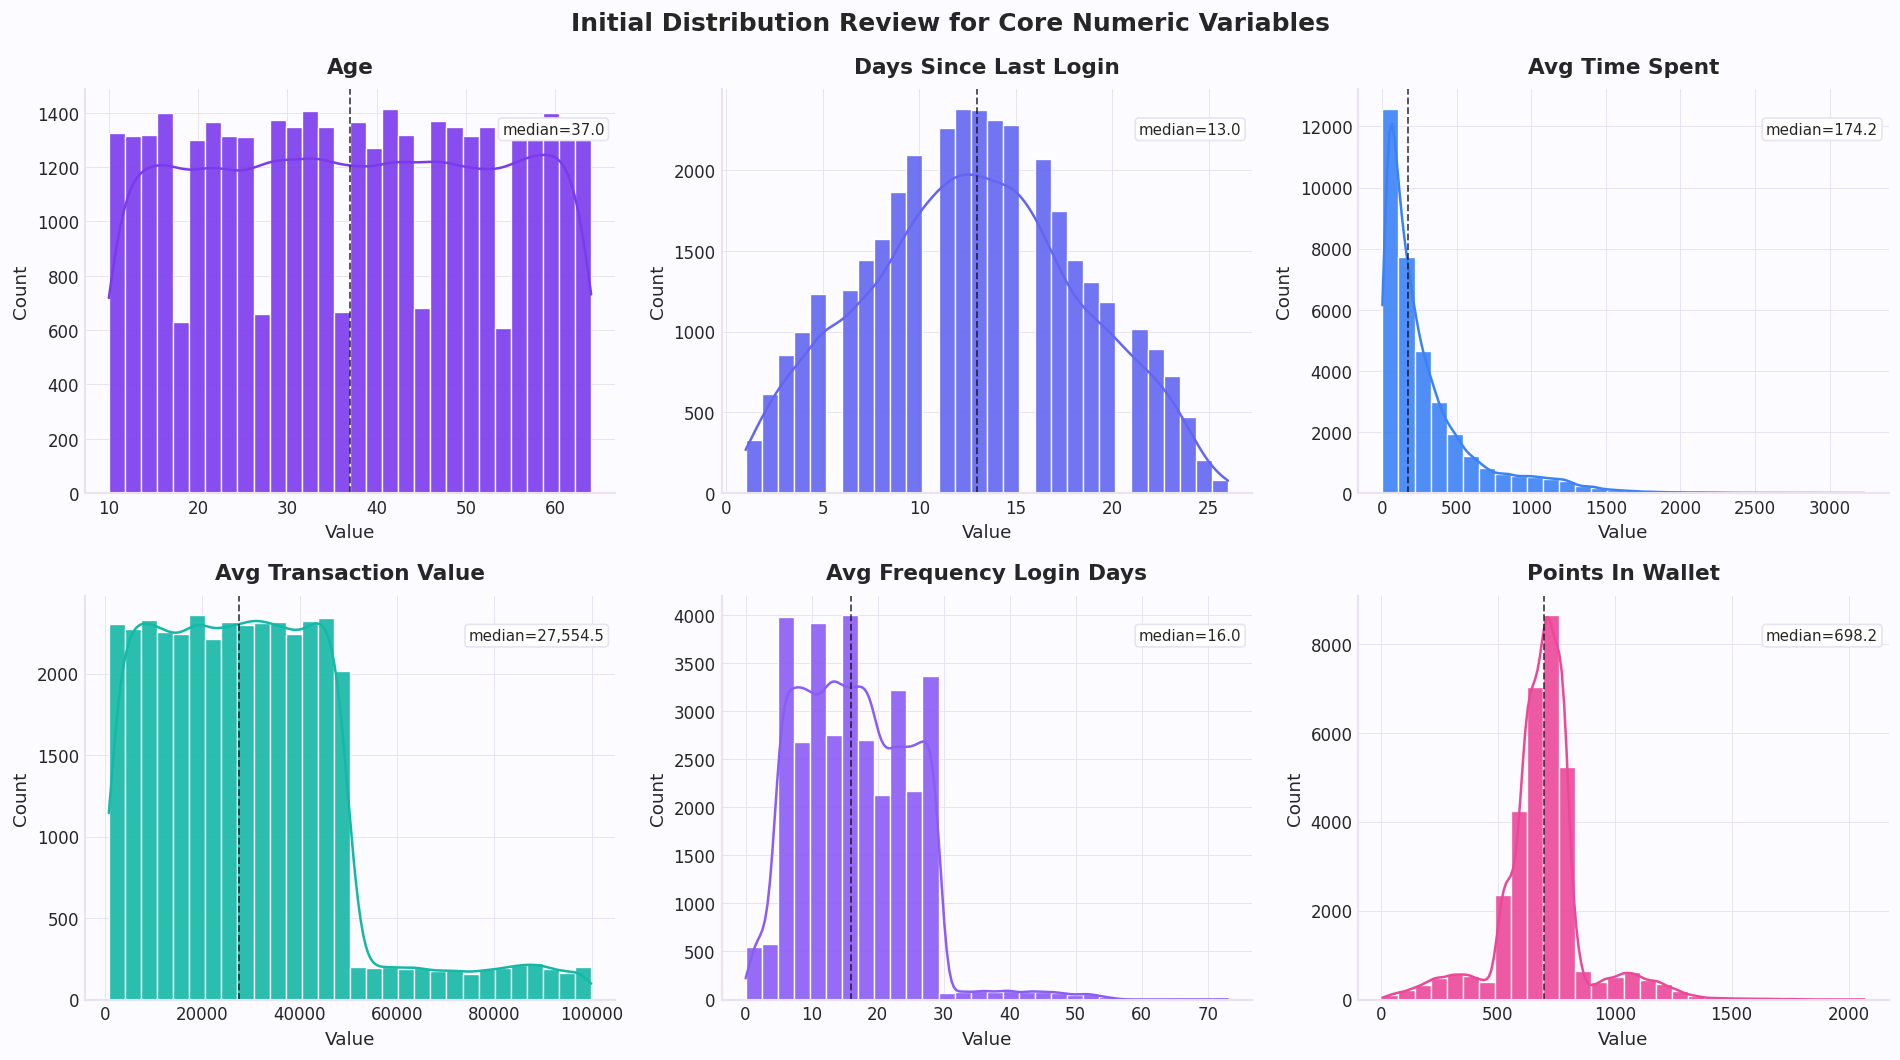

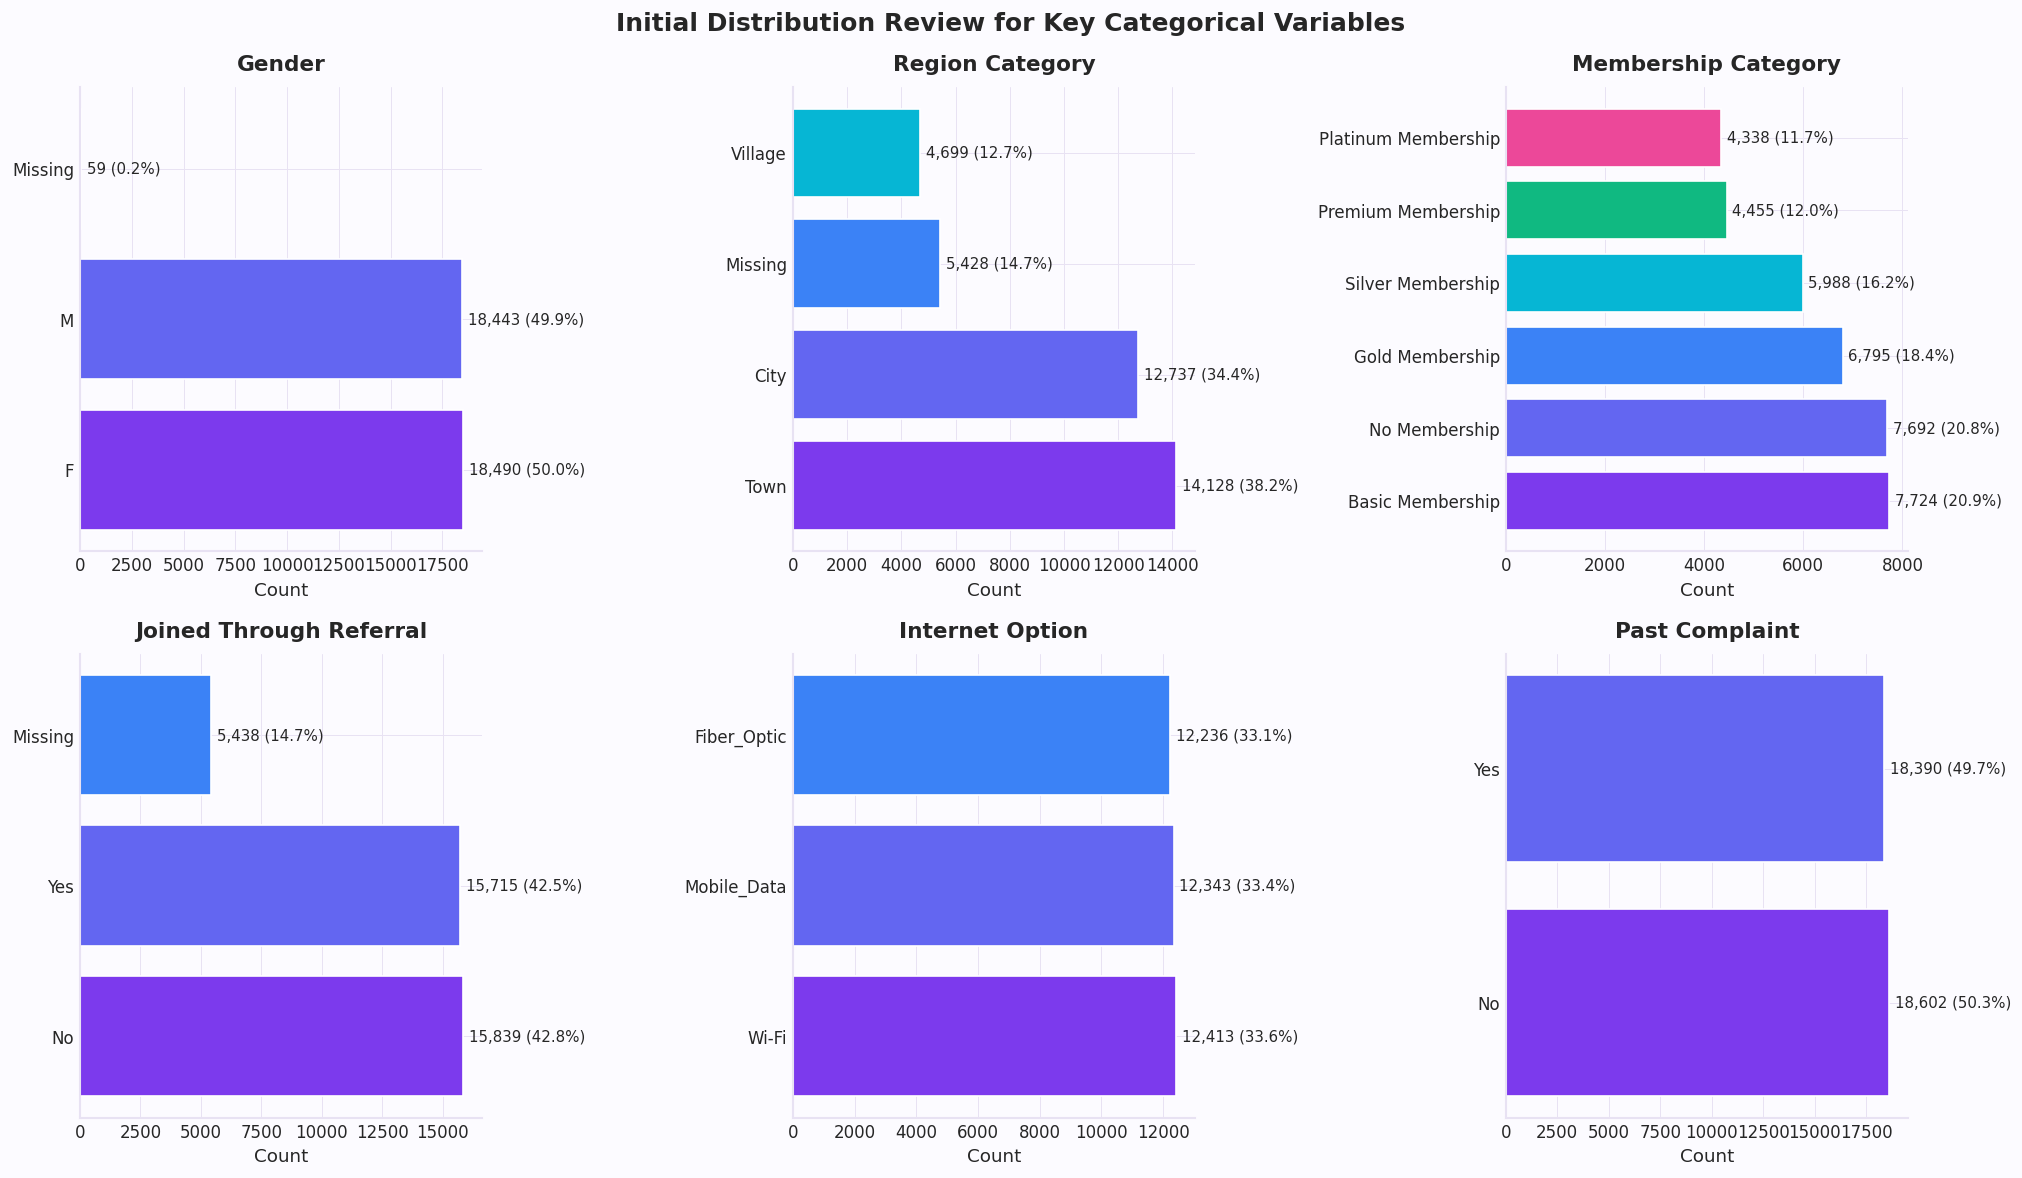

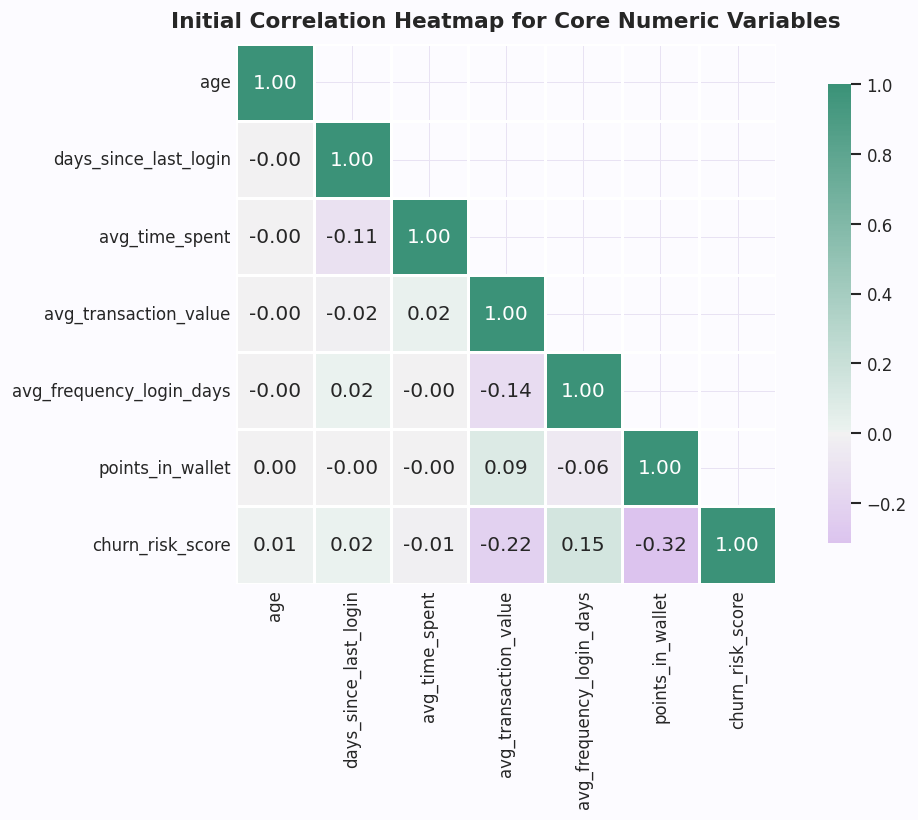

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Initial Distribution Review for Core Numeric Variables", fontsize=15, fontweight="bold")

for ax, col, accent in zip(axes.flat, numeric_cols, ACCENTS + [PALETTE["churn"]]):
    series = df_clean[col].dropna()
    sns.histplot(
        series,
        bins=30,
        kde=True,
        color=accent,
        edgecolor="white",
        alpha=0.9,
        ax=ax,
    )
    if not series.empty:
        ax.axvline(series.median(), color="#111111", linestyle="--", linewidth=1.1, alpha=0.75)
        ax.text(
            0.98,
            0.92,
            f"median={series.median():,.1f}",
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=9,
            bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "edgecolor": GRID_CLR},
        )
    style_ax(ax, col.replace("_", " ").title(), "Value", "Count")

plt.tight_layout()
plt.show()

initial_cat_plot_cols = [
    "gender",
    "region_category",
    "membership_category",
    "joined_through_referral",
    "internet_option",
    "past_complaint",
]

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle("Initial Distribution Review for Key Categorical Variables", fontsize=15, fontweight="bold")

for ax, col in zip(axes.flat, initial_cat_plot_cols):
    counts = df_clean[col].fillna("Missing").value_counts().head(8)
    palette = build_palette(len(counts))
    ax.barh(counts.index, counts.values, color=palette, edgecolor="white", linewidth=1.0)
    for i, value in enumerate(counts.values):
        pct = value / len(df_clean)
        ax.text(value + max(counts.values) * 0.015, i, f"{value:,} ({pct:.1%})", va="center", fontsize=9)
    style_ax(ax, col.replace("_", " ").title(), "Count", "")

plt.tight_layout()
plt.show()

plot_triangular_correlation_heatmap(
    df_clean,
    numeric_cols + [target],
    "Initial Correlation Heatmap for Core Numeric Variables",
)

### 2.4 Categorical Audit

In [7]:
categorical_audit_cols = [
    "gender",
    "region_category",
    "membership_category",
    "joined_through_referral",
    "preferred_offer_types",
    "medium_of_operation",
    "internet_option",
    "used_special_discount",
    "offer_application_preference",
    "past_complaint",
    "complaint_status",
    "feedback",
]

for col in categorical_audit_cols:
    print(f"\nColumn: {col}")
    print("-" * (8 + len(col)))
    print(f"Unique values: {df_clean[col].nunique(dropna=False)}")
    display(
        df_clean[col]
        .value_counts(dropna=False)
        .rename_axis(col)
        .reset_index(name="count")
    )


Column: gender
--------------
Unique values: 3


,gender,count
0,F,18490
1,M,18443
2,NaN,59



Column: region_category
-----------------------
Unique values: 4


,region_category,count
0,Town,14128
1,City,12737
2,NaN,5428
3,Village,4699



Column: membership_category
---------------------------
Unique values: 6


...

,past_complaint,count
0,No,18602
1,Yes,18390



Column: complaint_status
------------------------
Unique values: 5


,complaint_status,count
0,Not Applicable,18602
1,Unsolved,4644
2,Solved,4619
3,Solved in Follow-up,4577
4,No Information Available,4550



Column: feedback
----------------
Unique values: 9


,feedback,count
0,Poor Product Quality,6350
1,No reason specified,6290
2,Too many ads,6279
3,Poor Website,6271
4,Poor Customer Service,6252
5,Reasonable Price,1417
6,User Friendly Website,1391
7,Products always in Stock,1382
8,Quality Customer Care,1360


### 2.5 Feature Engineering for Exploration and Interpretation

Business-specific transformations are defined here, close to the point of use, while keeping
repeated binning logic concise and consistent.


FEATURE ENGINEERING
Created grouped and business-friendly features:
  • feedback_sentiment
  • complaint_status_group
  • age_group
  • login_recency_group
  • time_spent_group
  • transaction_value_group
  • login_frequency_group
  • wallet_points_group
  • visit_period
  • tenure_group
  • age_invalid
  • days_since_last_login_invalid
  • avg_time_spent_invalid
  • avg_transaction_value_invalid
  • avg_frequency_login_days_invalid
  • points_in_wallet_invalid
  • had_complaint
  • complaint_unresolved
  • relative_tenure_days
  • engagement_score
  • value_per_login


,feedback_sentiment,complaint_status_group,age_group,login_recency_group,time_spent_group,transaction_value_group,login_frequency_group,wallet_points_group,visit_period,tenure_group,age_invalid,days_since_last_login_invalid,avg_time_spent_invalid,avg_transaction_value_invalid,avg_frequency_login_days_invalid,points_in_wallet_invalid,had_complaint,complaint_unresolved,relative_tenure_days,engagement_score,value_per_login
0,Positive,No Complaint,Young,Inactive,High,High Value,Moderate Frequency,Medium Points,Afternoon,New,0,0,0,0,0,0,0,0,136,5110.71,2944.736111
1,Positive,Resolved,Adult,Inactive,High,Medium Value,Low Frequency,Invalid_or_Missing,Afternoon,New,0,0,0,0,0,0,1,0,125,3063.40,1167.125455
2,Negative,Resolved,Adult,Moderately Inactive,High,Medium Value,High Frequency,Medium Points,Night,Loyal,0,0,0,0,0,0,1,0,415,11355.52,914.217391
3,Negative,Unresolved_or_Unknown,Adult,Moderately Inactive,Low,Medium Value,Low Frequency,Medium Points,Afternoon,Loyal,0,0,0,0,0,0,1,1,428,319.62,3605.651429
4,Negative,Resolved,Adult,Inactive,Medium,Medium Value,Moderate Frequency,Medium Points,Afternoon,New,0,0,0,0,0,0,1,0,110,1810.08,1440.215294


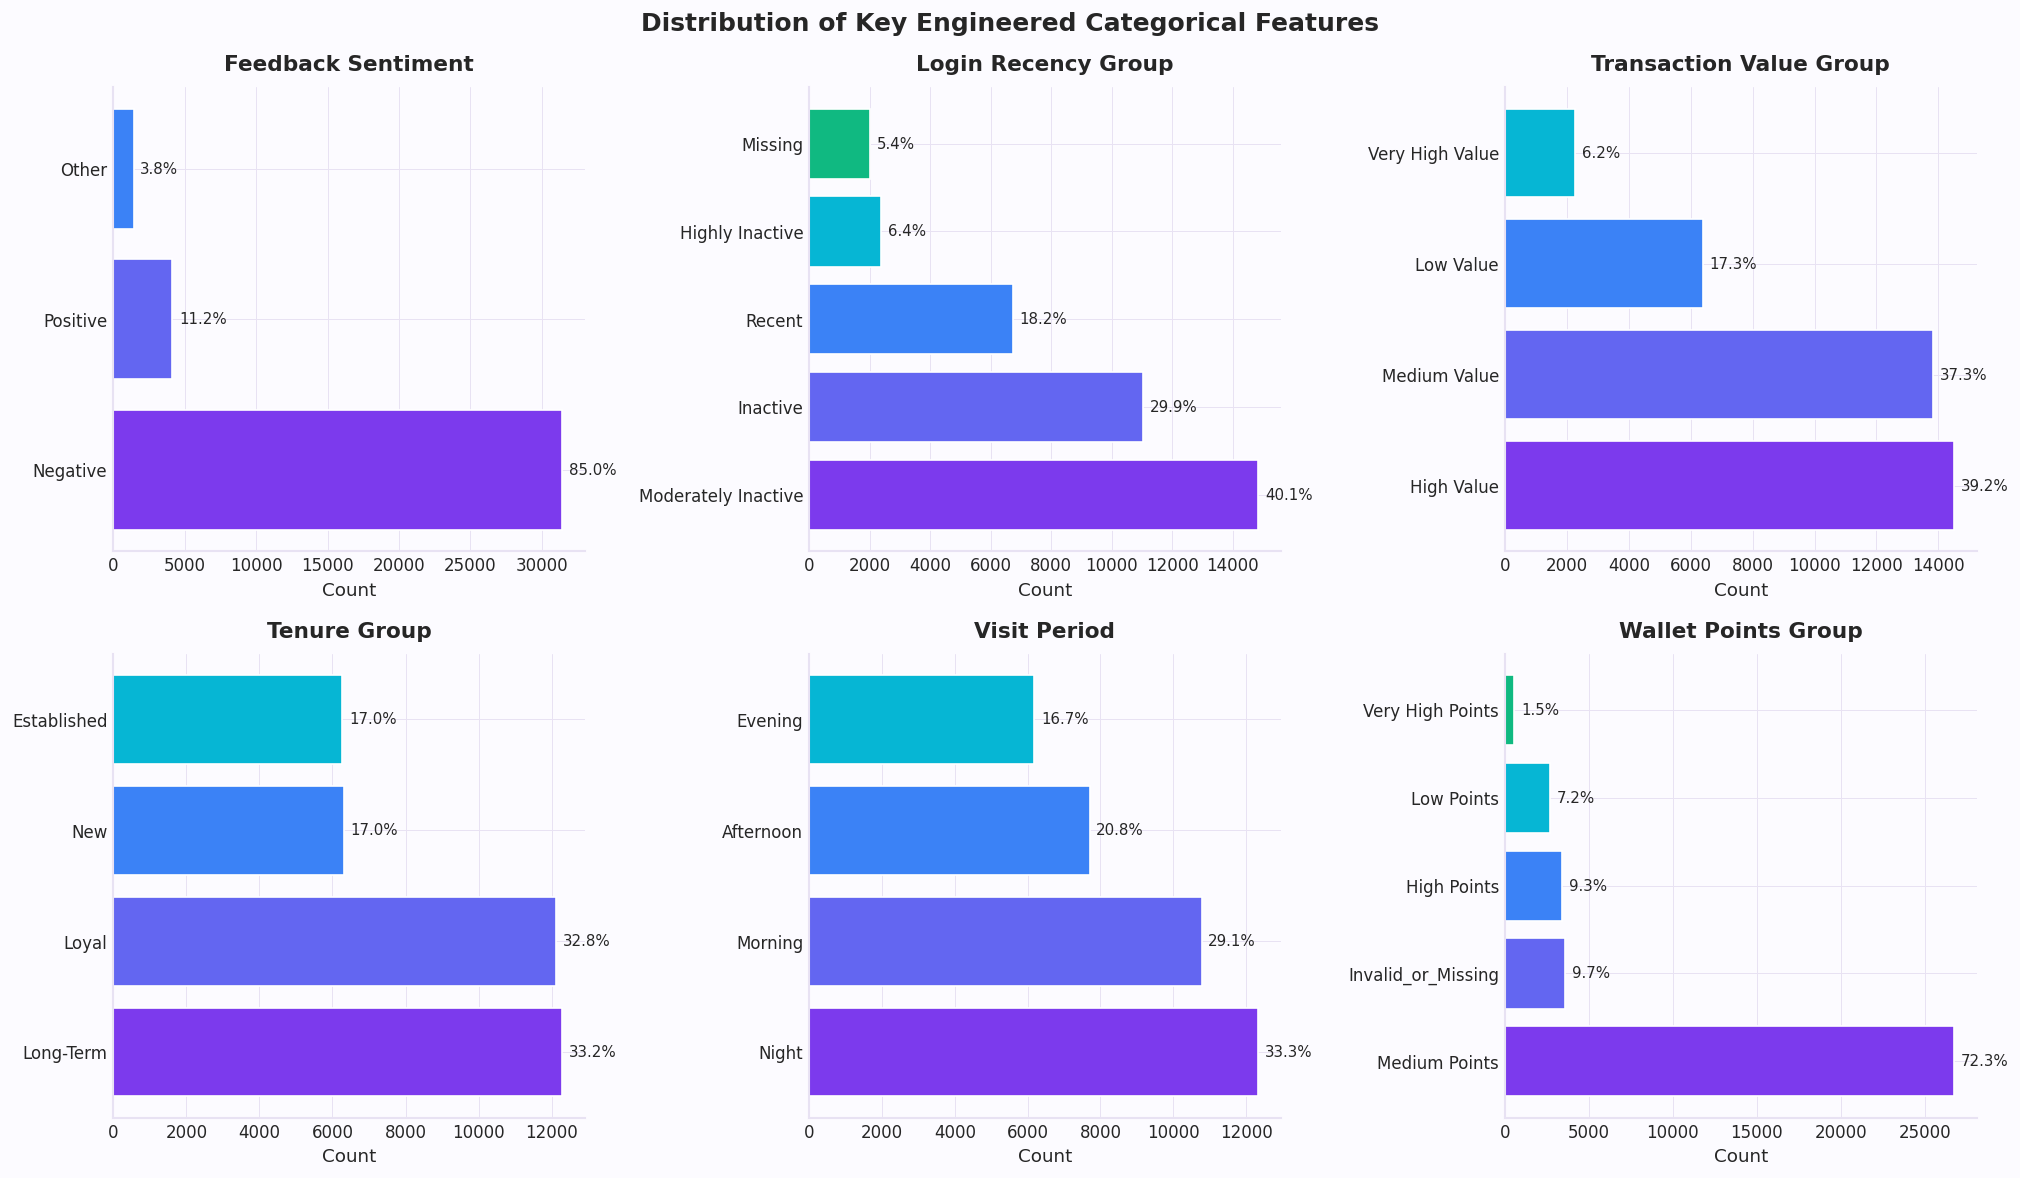

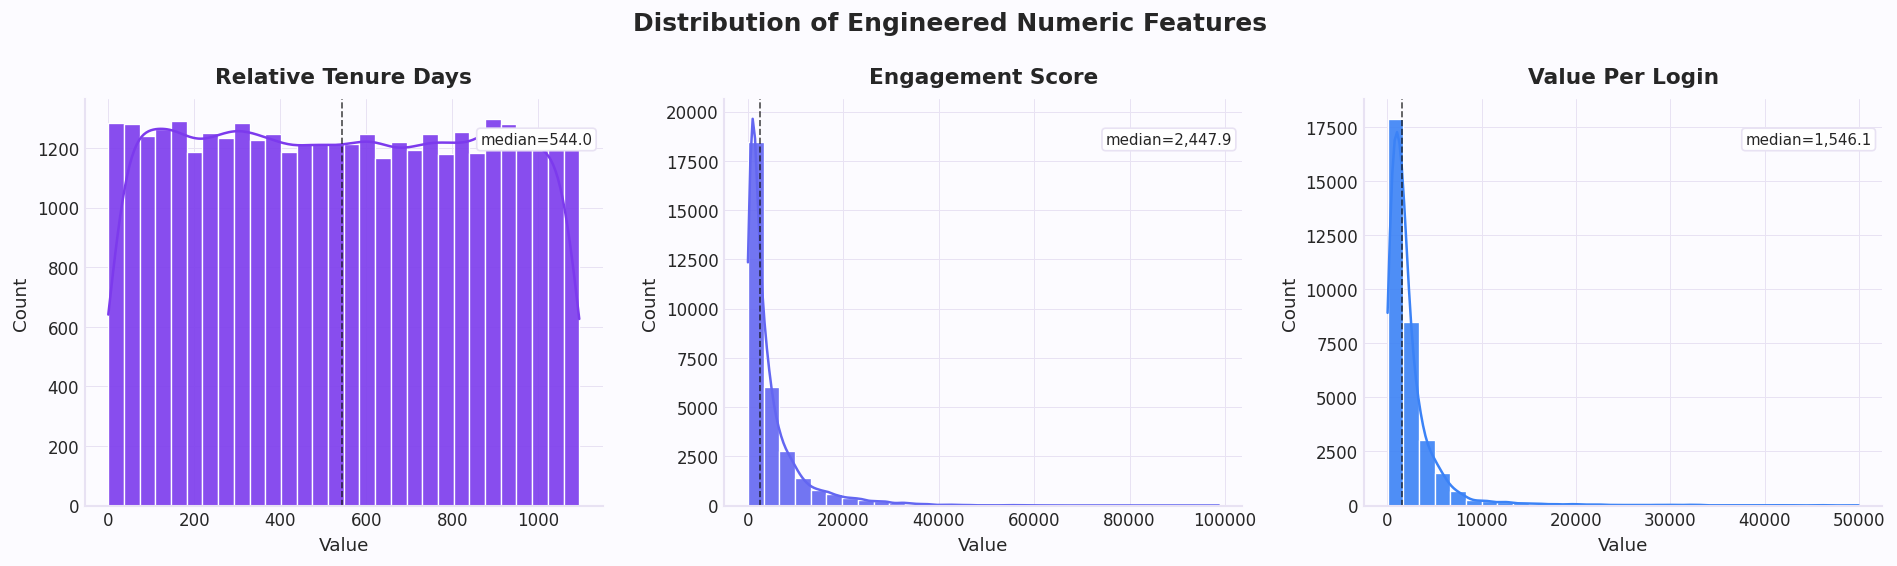

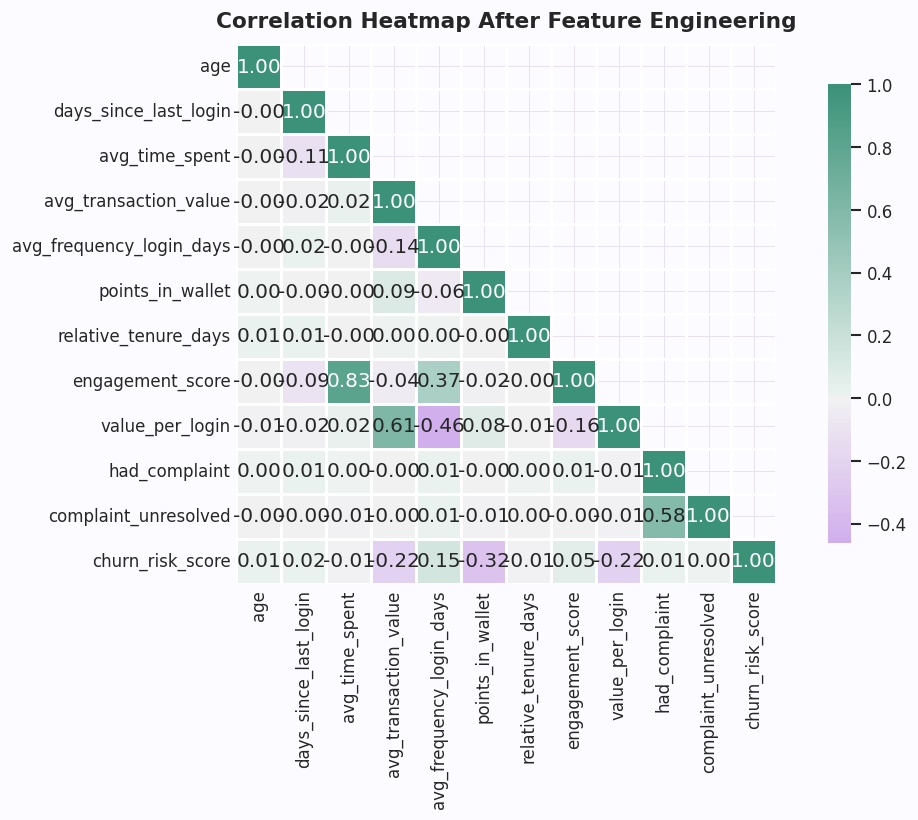

In [8]:
section_title("Feature Engineering")


def add_missing_label_from_source(
    category_series: pd.Series,
    source_series: pd.Series,
    label: str,
) -> pd.Series:
    output = category_series.astype("object")
    output.loc[source_series.isna()] = label
    return output


def build_binned_feature(
    data: pd.DataFrame,
    source_col: str,
    bins,
    labels,
    missing_label: str,
    right: bool = True,
) -> pd.Series:
    grouped = pd.cut(data[source_col], bins=bins, labels=labels, right=right)
    return add_missing_label_from_source(grouped, data[source_col], missing_label)

df_clean["joining_date"] = pd.to_datetime(df_clean["joining_date"], errors="coerce")
df_clean["last_visit_hour"] = pd.to_datetime(
    df_clean["last_visit_time"], format="%H:%M:%S", errors="coerce"
).dt.hour

reference_date = df_clean["joining_date"].max()
df_clean["relative_tenure_days"] = (reference_date - df_clean["joining_date"]).dt.days

df_clean["engagement_score"] = df_clean["avg_time_spent"] * df_clean["avg_frequency_login_days"]
df_clean["value_per_login"] = df_clean["avg_transaction_value"] / (df_clean["avg_frequency_login_days"] + 1)

# Business grouping dictionaries
feedback_map = {
    "Poor Website": "Negative",
    "Poor Product Quality": "Negative",
    "Poor Customer Service": "Negative",
    "Too many ads": "Negative",
    "Poor User Experience": "Negative",
    "No reason specified": "Negative",
    "Quality Customer Care": "Positive",
    "User Friendly Website": "Positive",
    "Products always in Stock": "Positive",
    "Missing": "Missing",
}

complaint_map = {
    "Not Applicable": "No Complaint",
    "Solved": "Resolved",
    "Solved in Follow-up": "Resolved",
    "Unsolved": "Unresolved_or_Unknown",
    "No Information Available": "Unresolved_or_Unknown",
    "Missing": "Missing",
}

df_clean["feedback_sentiment"] = df_clean["feedback"].map(feedback_map).fillna("Other")
df_clean["complaint_status_group"] = df_clean["complaint_status"].map(complaint_map).fillna("Other")

df_clean["had_complaint"] = df_clean["past_complaint"].eq("Yes").astype(int)
df_clean["complaint_unresolved"] = df_clean["complaint_status_group"].eq("Unresolved_or_Unknown").astype(int)

df_clean["age_group"] = build_binned_feature(
    df_clean,
    source_col="age",
    bins=[0, 25, 45, 65, np.inf],
    labels=["Young", "Adult", "Mature", "Senior"],
    missing_label="Missing",
    right=False,
)

df_clean["login_recency_group"] = build_binned_feature(
    df_clean,
    source_col="days_since_last_login",
    bins=[-np.inf, 7, 14, 21, np.inf],
    labels=["Recent", "Moderately Inactive", "Inactive", "Highly Inactive"],
    missing_label="Missing",
)

df_clean["time_spent_group"] = build_binned_feature(
    df_clean,
    source_col="avg_time_spent",
    bins=[-np.inf, 60, 180, np.inf],
    labels=["Low", "Medium", "High"],
    missing_label="Invalid_or_Missing",
)

df_clean["transaction_value_group"] = build_binned_feature(
    df_clean,
    source_col="avg_transaction_value",
    bins=[-np.inf, 10000, 30000, 60000, np.inf],
    labels=["Low Value", "Medium Value", "High Value", "Very High Value"],
    missing_label="Missing",
)

df_clean["login_frequency_group"] = build_binned_feature(
    df_clean,
    source_col="avg_frequency_login_days",
    bins=[-np.inf, 10, 20, 35, np.inf],
    labels=["Low Frequency", "Moderate Frequency", "High Frequency", "Very High Frequency"],
    missing_label="Invalid_or_Missing",
)

df_clean["wallet_points_group"] = build_binned_feature(
    df_clean,
    source_col="points_in_wallet",
    bins=[-np.inf, 500, 800, 1200, np.inf],
    labels=["Low Points", "Medium Points", "High Points", "Very High Points"],
    missing_label="Invalid_or_Missing",
)

visit_period_conditions = [
    df_clean["last_visit_hour"].between(5, 11, inclusive="both"),
    df_clean["last_visit_hour"].between(12, 16, inclusive="both"),
    df_clean["last_visit_hour"].between(17, 20, inclusive="both"),
]
visit_period_choices = ["Morning", "Afternoon", "Evening"]
df_clean["visit_period"] = np.select(visit_period_conditions, visit_period_choices, default="Night")
df_clean.loc[df_clean["last_visit_hour"].isna(), "visit_period"] = "Missing"

df_clean["tenure_group"] = pd.cut(
    df_clean["relative_tenure_days"],
    bins=[-1, 180, 365, 730, np.inf],
    labels=["New", "Established", "Loyal", "Long-Term"],
)
df_clean["relative_tenure_bin"] = pd.cut(df_clean["relative_tenure_days"], bins=5)
df_clean["joining_month"] = df_clean["joining_date"].dt.to_period("M")

engineered_feature_cols = [
    "feedback_sentiment",
    "complaint_status_group",
    "age_group",
    "login_recency_group",
    "time_spent_group",
    "transaction_value_group",
    "login_frequency_group",
    "wallet_points_group",
    "visit_period",
    "tenure_group",
    "age_invalid",
    "days_since_last_login_invalid",
    "avg_time_spent_invalid",
    "avg_transaction_value_invalid",
    "avg_frequency_login_days_invalid",
    "points_in_wallet_invalid",
    "had_complaint",
    "complaint_unresolved",
    "relative_tenure_days",
    "engagement_score",
    "value_per_login",
]

print("Created grouped and business-friendly features:")
for col in engineered_feature_cols:
    print(f"  • {col}")

display(df_clean[engineered_feature_cols].head())

engineered_group_plot_cols = [
    "feedback_sentiment",
    "login_recency_group",
    "transaction_value_group",
    "tenure_group",
    "visit_period",
    "wallet_points_group",
]

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle("Distribution of Key Engineered Categorical Features", fontsize=15, fontweight="bold")

for ax, col in zip(axes.flat, engineered_group_plot_cols):
    counts = df_clean[col].astype("object").fillna("Missing").value_counts(dropna=False)
    palette = build_palette(len(counts))
    ax.barh(counts.index.astype(str), counts.values, color=palette, edgecolor="white", linewidth=1.0)
    for i, value in enumerate(counts.values):
        pct = value / len(df_clean)
        ax.text(value + max(counts.values) * 0.015, i, f"{pct:.1%}", va="center", fontsize=9)
    style_ax(ax, col.replace("_", " ").title(), "Count", "")

plt.tight_layout()
plt.show()

engineered_numeric_plot_cols = [
    "relative_tenure_days",
    "engagement_score",
    "value_per_login",
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
fig.suptitle("Distribution of Engineered Numeric Features", fontsize=15, fontweight="bold")

for ax, col, color in zip(axes.flat, engineered_numeric_plot_cols, build_palette(3)):
    series = df_clean[col].dropna()
    sns.histplot(
        series,
        bins=30,
        kde=True,
        color=color,
        edgecolor="white",
        alpha=0.9,
        ax=ax,
    )
    if not series.empty:
        ax.axvline(series.median(), color="#111111", linestyle="--", linewidth=1.0, alpha=0.75)
        ax.text(
            0.98,
            0.92,
            f"median={series.median():,.1f}",
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=9,
            bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "edgecolor": GRID_CLR},
        )
    style_ax(ax, col.replace("_", " ").title(), "Value", "Count")

plt.tight_layout()
plt.show()

engineered_corr_cols = [
    "age",
    "days_since_last_login",
    "avg_time_spent",
    "avg_transaction_value",
    "avg_frequency_login_days",
    "points_in_wallet",
    "relative_tenure_days",
    "engagement_score",
    "value_per_login",
    "had_complaint",
    "complaint_unresolved",
    target,
]

plot_triangular_correlation_heatmap(
    df_clean,
    engineered_corr_cols,
    "Correlation Heatmap After Feature Engineering",
)

### 2.6 Exploratory Analysis

The grouped summaries below show both conditional churn rates within each segment and each segment's
contribution to total churners. These answer different questions and should be interpreted together.


EXPLORATORY ANALYSIS


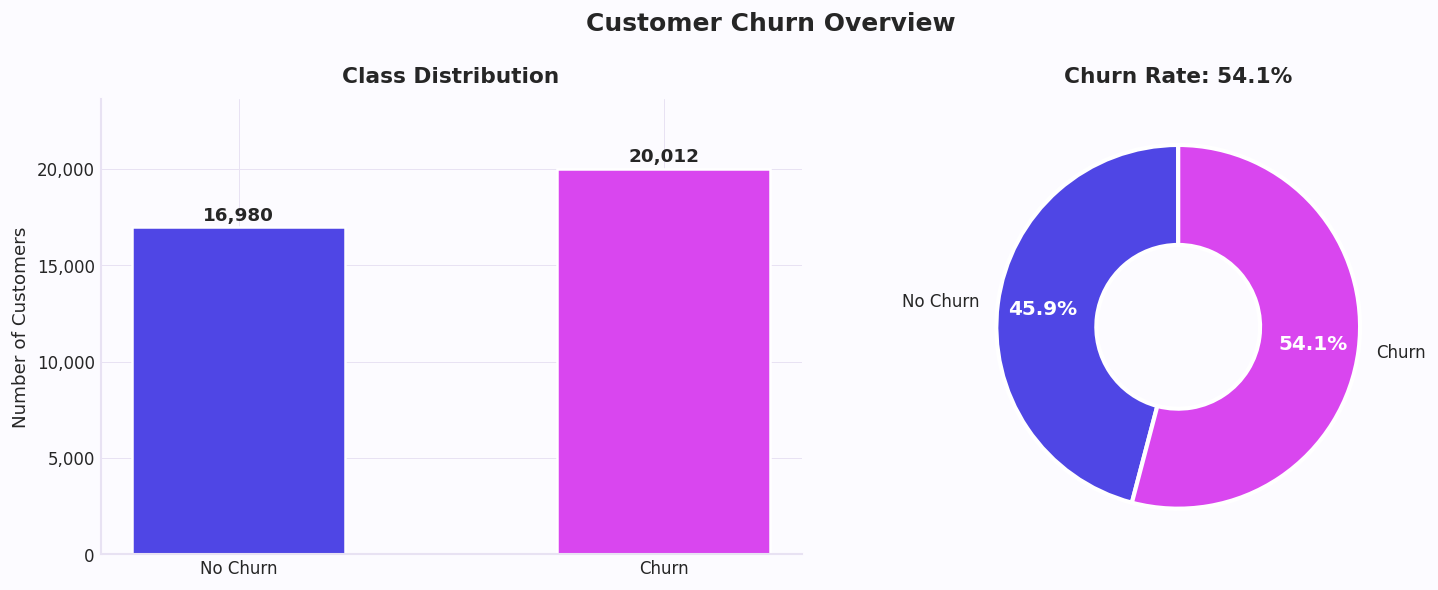

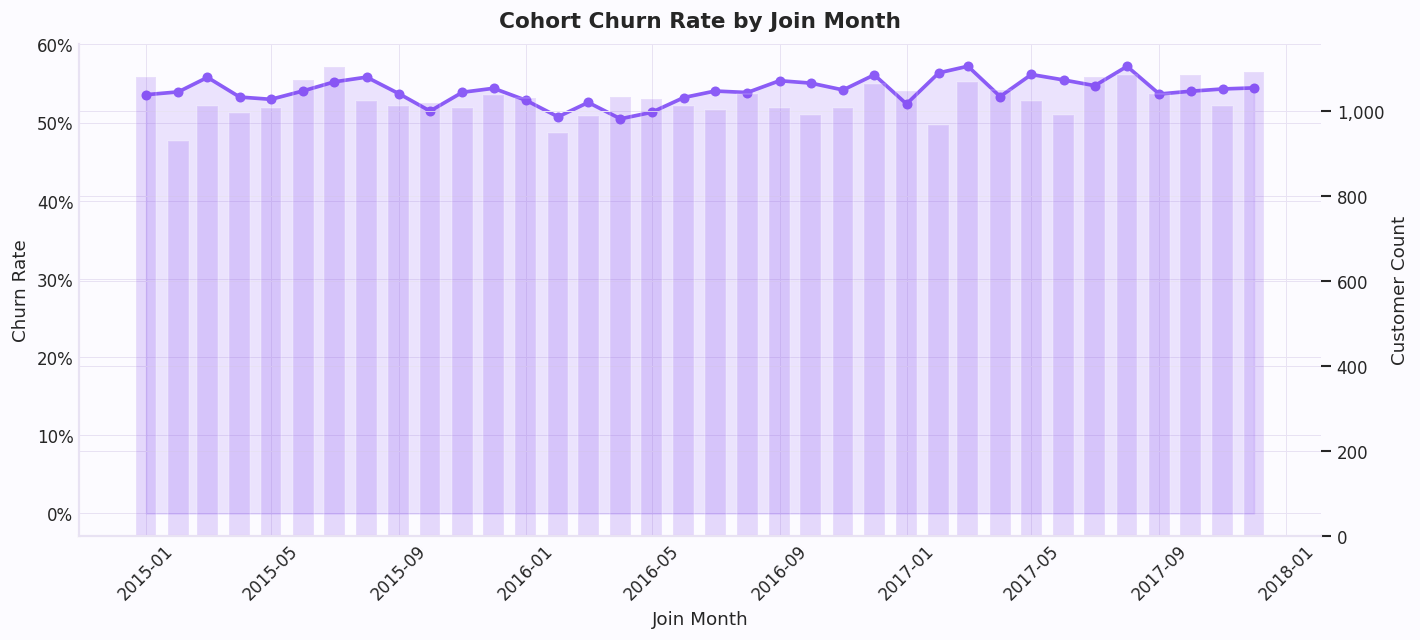


Join-month cohort note: this chart shows the eventual churn rate of customers grouped by the month they joined. It is a cohort-style view, not a true month-by-month churn event trend, because the dataset does not include a separate churn date.


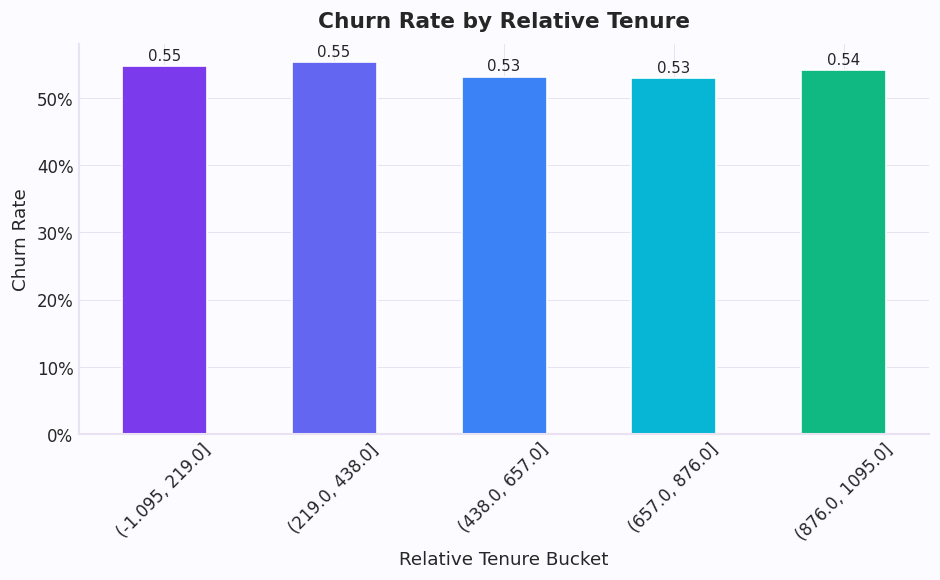

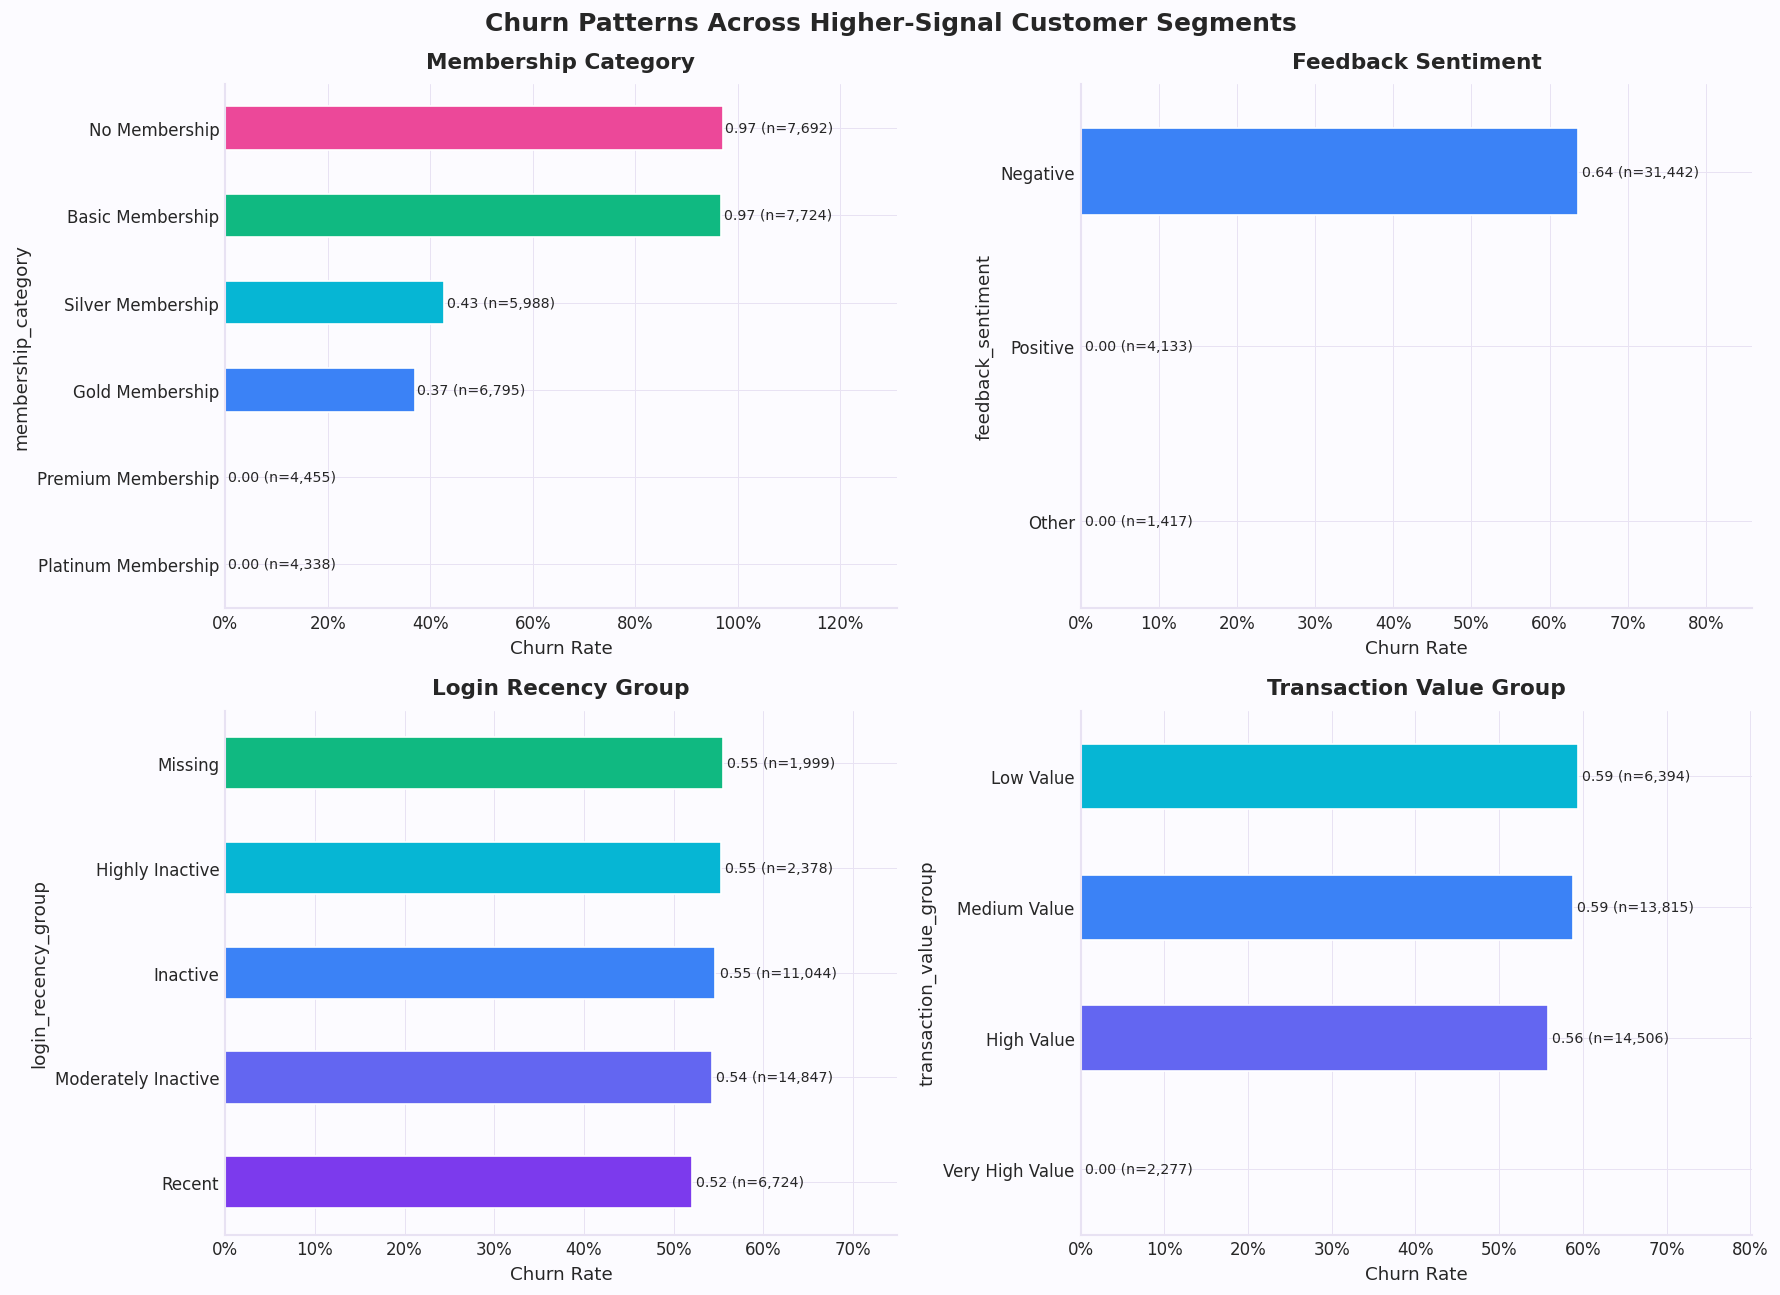

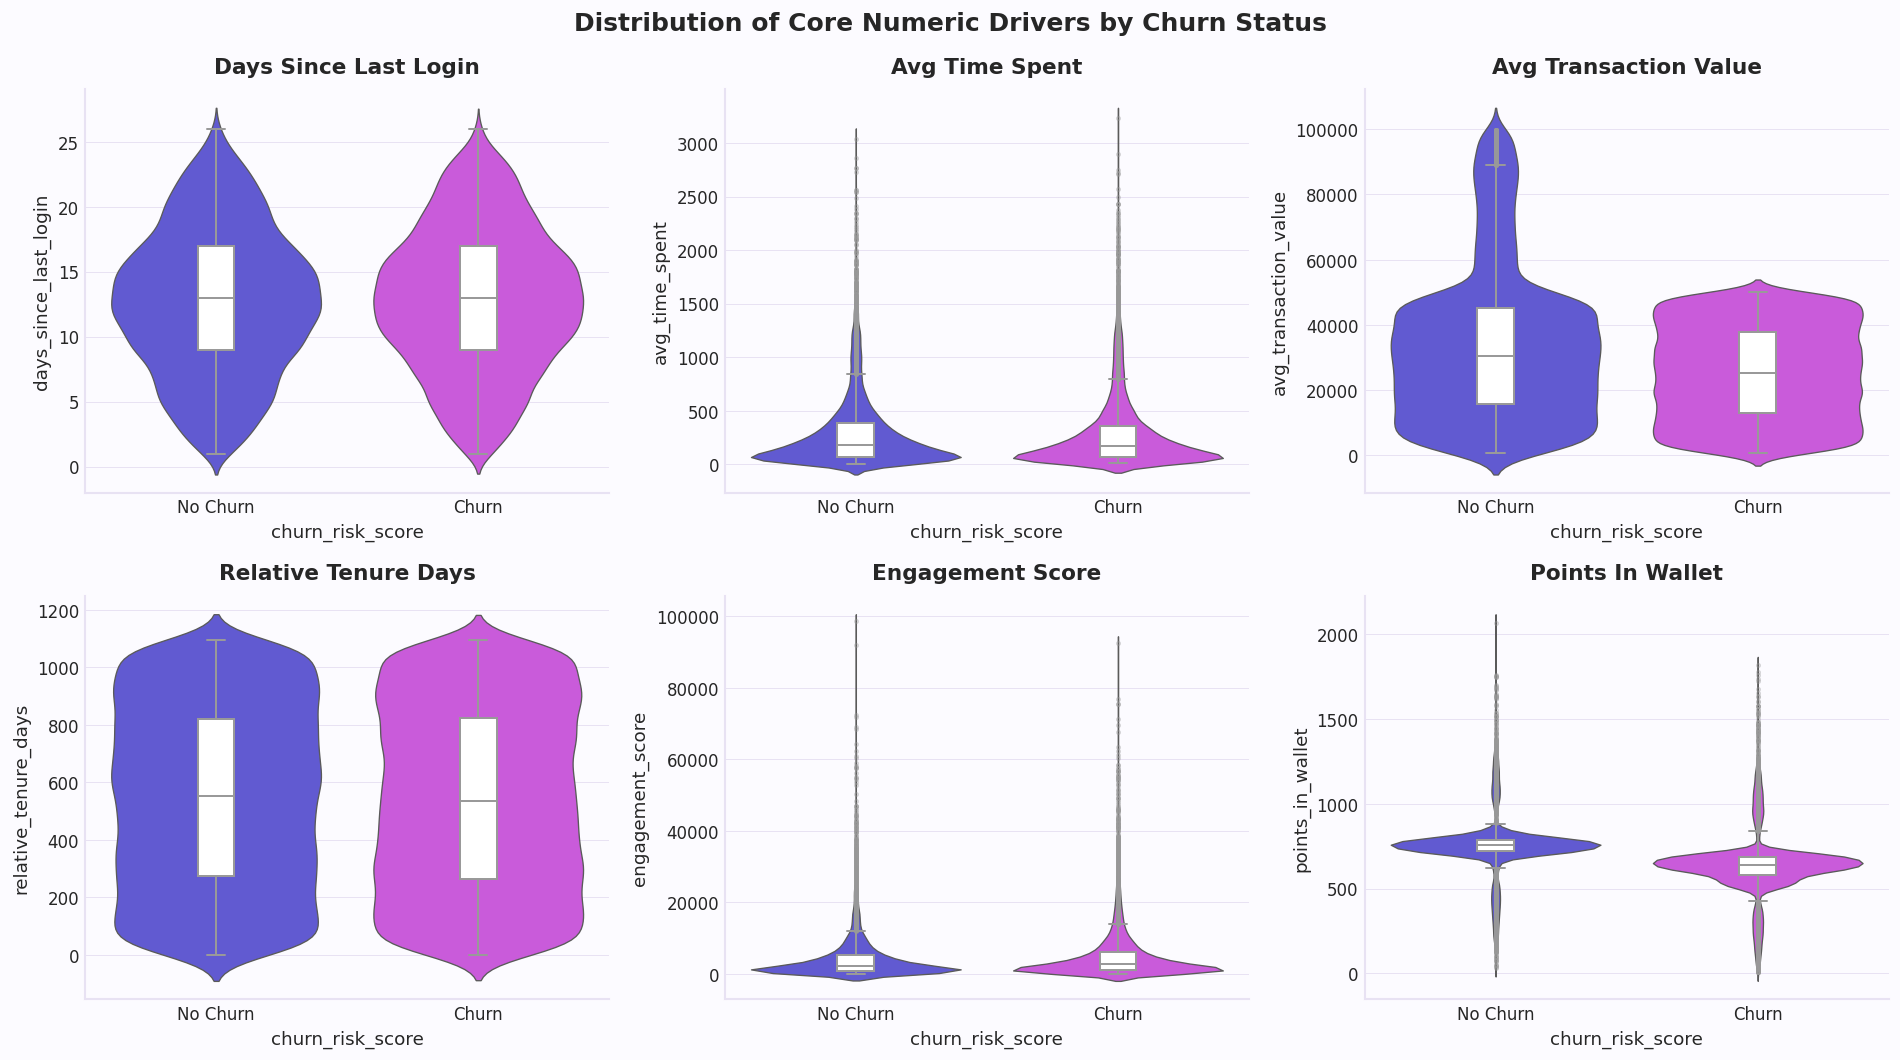


Note: `within_group_churn_rate` is the churn rate inside a segment, while `share_of_total_churners` shows how much that segment contributes to all churners. Within-group churn rates do not sum to 1 because they are conditional rates, not shares of the full dataset.

Target summary by feedback_sentiment


,within_group_churn_rate,group_size,churners_in_group,share_of_total_churners
feedback_sentiment,,,,
Negative,63.65%,"31,442","20,012",100.00%
Positive,0.00%,"4,133",0,0.00%
Other,0.00%,"1,417",0,0.00%



Target summary by complaint_status_group


,within_group_churn_rate,group_size,churners_in_group,share_of_total_churners
complaint_status_group,,,,
Resolved,54.82%,"9,196","5,041",25.19%
Unresolved_or_Unknown,54.27%,"9,194","4,990",24.94%
No Complaint,53.66%,"18,602","9,981",49.88%



Target summary by age_group


...

,within_group_churn_rate,group_size,churners_in_group,share_of_total_churners
wallet_points_group,,,,
Low Points,56.18%,"2,679","1,505",7.52%
Medium Points,55.78%,"26,740","14,915",74.53%
Invalid_or_Missing,54.85%,"3,579","1,963",9.81%
High Points,42.60%,"3,427","1,460",7.30%
Very High Points,29.81%,567,169,0.84%



Target summary by visit_period


,within_group_churn_rate,group_size,churners_in_group,share_of_total_churners
visit_period,,,,
Morning,54.66%,"10,778","5,891",29.44%
Evening,53.97%,"6,181","3,336",16.67%
Night,53.86%,"12,334","6,643",33.20%
Afternoon,53.80%,"7,699","4,142",20.70%



Target summary by tenure_group


,within_group_churn_rate,group_size,churners_in_group,share_of_total_churners
tenure_group,,,,
Established,55.14%,"6,271","3,458",17.28%
New,54.69%,"6,305","3,448",17.23%
Long-Term,54.01%,"12,297","6,642",33.19%
Loyal,53.34%,"12,119","6,464",32.30%


In [9]:
section_title("Exploratory Analysis")

counts = df_clean[target].value_counts().sort_index()
labels = ["No Churn", "Churn"]
churn_rate = df_clean[target].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Customer Churn Overview", fontsize=15, fontweight="bold")

bars = axes[0].bar(labels, counts.values, color=COLORS, width=0.5, edgecolor="white", linewidth=1.5)
for bar, val in zip(bars, counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 150,
        f"{val:,}",
        ha="center",
        va="bottom",
        fontweight="bold",
        fontsize=11,
    )

axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
axes[0].set_ylim(0, counts.max() * 1.18)
style_ax(axes[0], "Class Distribution", "", "Number of Customers")

wedges, texts, autotexts = axes[1].pie(
    counts.values,
    labels=labels,
    colors=COLORS,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.75,
    wedgeprops={"width": 0.55, "edgecolor": "white", "linewidth": 2.5},
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight("bold")
    at.set_color("white")

axes[1].set_title(f"Churn Rate: {churn_rate:.1%}", pad=10, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Join-month cohort trend
trend_df = (
    df_clean.assign(join_year_month=df_clean["joining_date"].dt.to_period("M").dt.to_timestamp())
    .groupby("join_year_month")
    .agg(churn_rate=(target, "mean"), customer_count=(target, "size"))
    .reset_index()
    .sort_values("join_year_month")
)

fig, ax = plt.subplots(figsize=(12, 5.5))
ax2 = ax.twinx()
ax.plot(
    trend_df["join_year_month"],
    trend_df["churn_rate"],
    marker="o",
    linewidth=2.2,
    color=ACCENTS[4],
    markersize=5,
)
ax.fill_between(
    trend_df["join_year_month"],
    trend_df["churn_rate"],
    color=ACCENTS[4],
    alpha=0.15,
)
ax2.bar(
    trend_df["join_year_month"],
    trend_df["customer_count"],
    color=ACCENTS[0],
    alpha=0.18,
    width=20,
)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.tick_params(axis="x", rotation=45)
style_ax(ax, "Cohort Churn Rate by Join Month", "Join Month", "Churn Rate")
ax2.set_ylabel("Customer Count")
plt.tight_layout()
plt.show()

print(
    "\nJoin-month cohort note: this chart shows the eventual churn rate of customers grouped by the month "
    "they joined. It is a cohort-style view, not a true month-by-month churn event trend, because the "
    "dataset does not include a separate churn date."
)

tenure_churn = df_clean.groupby("relative_tenure_bin")[target].mean()

fig, ax = plt.subplots(figsize=(8, 5))
tenure_churn.plot(kind="bar", ax=ax, color=build_palette(len(tenure_churn)), edgecolor="white")
for bar, val in zip(ax.patches, tenure_churn):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{val:.2f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )
style_ax(ax, "Churn Rate by Relative Tenure", "Relative Tenure Bucket", "Churn Rate")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0%}"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

engineered_numerical = [
    "days_since_last_login",
    "avg_time_spent",
    "avg_transaction_value",
    "relative_tenure_days",
    "engagement_score",
    "points_in_wallet",
]

cat_features = [
    ("membership_category", "Membership Category"),
    ("feedback_sentiment", "Feedback Sentiment"),
    ("login_recency_group", "Login Recency Group"),
    ("transaction_value_group", "Transaction Value Group"),
]

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle("Churn Patterns Across Higher-Signal Customer Segments", fontsize=15, fontweight="bold")

for ax, (col, title) in zip(axes.flat, cat_features):
    churn_rate_by_cat = df_clean.groupby(col)[target].mean().sort_values()
    counts_by_cat = df_clean[col].value_counts(dropna=False)

    churn_rate_by_cat.plot(
        kind="barh",
        ax=ax,
        color=build_palette(len(churn_rate_by_cat)),
        edgecolor="white",
    )
    for i, (cat, val) in enumerate(churn_rate_by_cat.items()):
        n = counts_by_cat.get(cat, 0)
        ax.text(val + 0.005, i, f"{val:.2f} (n={n:,})", va="center", fontsize=8.5)

    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0%}"))
    ax.set_xlim(0, churn_rate_by_cat.max() * 1.35 if churn_rate_by_cat.max() > 0 else 1)
    style_ax(ax, title, "Churn Rate", "")

plt.tight_layout()
plt.show()

plot_df = df_clean[engineered_numerical + [target]].copy()
plot_df[target] = plot_df[target].map({0: "No Churn", 1: "Churn"})

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Distribution of Core Numeric Drivers by Churn Status", fontsize=15, fontweight="bold")

for ax, col in zip(axes.flat, engineered_numerical):
    sns.violinplot(
        data=plot_df,
        x=target,
        y=col,
        palette=COLORS,
        order=["No Churn", "Churn"],
        inner=None,
        linewidth=0.8,
        ax=ax,
    )
    sns.boxplot(
        data=plot_df,
        x=target,
        y=col,
        order=["No Churn", "Churn"],
        width=0.14,
        color="white",
        linewidth=1.2,
        flierprops={"marker": "o", "markersize": 2, "alpha": 0.4},
        ax=ax,
    )
    style_ax(ax, col.replace("_", " ").title(), "", "")

plt.tight_layout()
plt.show()

grouped_eda_cols = [
    "feedback_sentiment",
    "complaint_status_group",
    "age_group",
    "login_recency_group",
    "time_spent_group",
    "transaction_value_group",
    "login_frequency_group",
    "wallet_points_group",
    "visit_period",
    "tenure_group",
]

print(
    "\nNote: `within_group_churn_rate` is the churn rate inside a segment, while "
    "`share_of_total_churners` shows how much that segment contributes to all churners. "
    "Within-group churn rates do not sum to 1 because they are conditional rates, not shares of the full dataset."
)

total_churners = df_clean[target].sum()

for col in grouped_eda_cols:
    summary = (
        df_clean.groupby(col, dropna=False)[target]
        .agg(["mean", "count", "sum"])
        .rename(
            columns={
                "mean": "within_group_churn_rate",
                "count": "group_size",
                "sum": "churners_in_group",
            }
        )
        .assign(share_of_total_churners=lambda x: x["churners_in_group"] / total_churners)
        .sort_values(["within_group_churn_rate", "group_size"], ascending=[False, False])
    )
    print(f"\nTarget summary by {col}")
    display(
        summary.style.format(
            {
                "within_group_churn_rate": "{:.2%}",
                "group_size": "{:,.0f}",
                "churners_in_group": "{:,.0f}",
                "share_of_total_churners": "{:.2%}",
            }
        )
    )

### 2.7 Key Insights for the Business

- churn is not extremely imbalanced, which supports standard classification approaches
- grouped behavioural features such as login recency, time spent, and transaction value provide
  more business-friendly insight than raw values alone
- both within-group churn rates and share-of-total-churner metrics matter: a small segment can have
  high risk without driving most churn volume, while a large segment can matter operationally even if
  its churn rate is closer to average
- complaint and feedback related variables appear important, though they may also be close to the
  target timing and should be interpreted carefully
- the data quality issues are material enough that cleaning choices need to be clearly documented

## 3. Exercise 2, Predictive Modelling and Advanced Insights

### 3.1 Modelling Objective

The modelling objective is to predict the binary churn target provided in the dataset and produce
insights that can help the Family Experience team prioritise intervention.

### 3.2 Modelling Assumptions and Design Choices

Main modelling decisions:

- **Problem type**: binary classification, using the supplied target
- **Features**: raw numeric variables retained for predictive strength, grouped variables added for interpretability
- **Validation**: stratified train-test split and stratified cross-validation on the training set
- **Metrics**: F1, confusion matrix, precision, recall, and ROC-AUC
- **Explainability**: feature importance where available, plus permutation importance for model-agnostic interpretation

In [10]:
section_title("Exercise 2 - Prepare Data for Modelling")

drop_columns = id_columns + date_columns + ["joining_month", "relative_tenure_bin"]

df_model = df_clean.drop(columns=[c for c in drop_columns if c in df_clean.columns])

raw_numeric_features = [
    "age",
    "days_since_last_login",
    "avg_time_spent",
    "avg_transaction_value",
    "avg_frequency_login_days",
    "points_in_wallet",
    "relative_tenure_days",
    "engagement_score",
    "value_per_login",
    "last_visit_hour",
]

flag_features = [
    "age_invalid",
    "days_since_last_login_invalid",
    "avg_time_spent_invalid",
    "avg_transaction_value_invalid",
    "avg_frequency_login_days_invalid",
    "points_in_wallet_invalid",
    "had_complaint",
    "complaint_unresolved",
]

grouped_categorical_features = [
    "gender",
    "region_category",
    "membership_category",
    "joined_through_referral",
    "preferred_offer_types",
    "medium_of_operation",
    "internet_option",
    "used_special_discount",
    "offer_application_preference",
    "feedback_sentiment",
    "complaint_status_group",
    "age_group",
    "login_recency_group",
    "time_spent_group",
    "transaction_value_group",
    "login_frequency_group",
    "wallet_points_group",
    "visit_period",
    "tenure_group",
]

X = df_model.drop(columns=[target])
y = df_model[target]

print(f"Features: {X.shape[1]}")
print(f"Samples: {X.shape[0]}")
print(f"\nTarget distribution:\n{y.value_counts()}")


EXERCISE 2 - PREPARE DATA FOR MODELLING
Features: 40
Samples: 36992

Target distribution:
churn_risk_score
1    20012
0    16980
Name: count, dtype: int64


### 3.3 Train-Test Split

In [11]:
section_title("Train Test Split")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nTrain churn rate: {y_train.mean():.2%}")
print(f"Test churn rate: {y_test.mean():.2%}")


TRAIN TEST SPLIT
Training set: 29593 samples
Test set: 7399 samples

Train churn rate: 54.10%
Test churn rate: 54.10%


### 3.4 Preprocessing Pipeline

In [12]:
section_title("Preprocessing Pipelines")


def evaluate_candidate_on_test(
    name: str,
    pipeline: Pipeline,
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    y_train: pd.Series,
    y_test: pd.Series,
) -> Dict[str, float]:
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    return {
        "Model": name,
        "Test F1": f1_score(y_test, y_pred),
        "Test Precision": precision_score(y_test, y_pred),
        "Test Recall": recall_score(y_test, y_pred),
        "Test ROC-AUC": roc_auc_score(y_test, y_proba),
    }


def evaluate_model(
    pipeline: Pipeline,
    X_tr: pd.DataFrame,
    X_te: pd.DataFrame,
    y_tr: pd.Series,
    y_te: pd.Series,
    model_name: str,
) -> Dict[str, float]:
    y_train_pred = pipeline.predict(X_tr)
    y_test_pred = pipeline.predict(X_te)
    y_test_proba = pipeline.predict_proba(X_te)[:, 1]

    print(f"\n{'=' * 60}")
    print(f"{model_name} - Final Evaluation")
    print(f"{'=' * 60}")

    print("\nTrain Metrics:")
    print(f"  F1:        {f1_score(y_tr, y_train_pred):.4f}")
    print(f"  Precision: {precision_score(y_tr, y_train_pred):.4f}")
    print(f"  Recall:    {recall_score(y_tr, y_train_pred):.4f}")

    print("\nTest Metrics:")
    print(f"  F1:        {f1_score(y_te, y_test_pred):.4f}")
    print(f"  Precision: {precision_score(y_te, y_test_pred):.4f}")
    print(f"  Recall:    {recall_score(y_te, y_test_pred):.4f}")
    print(f"  ROC-AUC:   {roc_auc_score(y_te, y_test_proba):.4f}")

    print("\nClassification Report, Test:")
    print(classification_report(y_te, y_test_pred, target_names=["No Churn", "Churn"]))

    cm = confusion_matrix(y_te, y_test_pred)
    fpr, tpr, _ = roc_curve(y_te, y_test_proba)
    auc_val = roc_auc_score(y_te, y_test_proba)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f"{model_name} - Final Evaluation on Held-Out Test Set", fontsize=14, fontweight="bold")

    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    annot = np.array(
        [
            [f"{count:,}\n({pct:.1f}%)" for count, pct in zip(row_counts, row_pcts)]
            for row_counts, row_pcts in zip(cm, cm_pct)
        ]
    )

    sns.heatmap(
        cm,
        annot=annot,
        fmt="",
        cmap=CONFUSION_CMAP,
        linewidths=1,
        linecolor="white",
        annot_kws={"size": 11},
        xticklabels=["No Churn", "Churn"],
        yticklabels=["No Churn", "Churn"],
        ax=axes[0],
        cbar_kws={"shrink": 0.8},
    )
    style_ax(axes[0], "Confusion Matrix", "Predicted", "Actual")

    axes[1].plot(fpr, tpr, color=ACCENTS[4], lw=2.5, label=f"AUC = {auc_val:.4f}")
    axes[1].fill_between(fpr, tpr, alpha=0.08, color=ACCENTS[4])
    axes[1].plot([0, 1], [0, 1], "k--", lw=1, alpha=0.4, label="Random")
    axes[1].set_xlim([-0.01, 1.01])
    axes[1].set_ylim([-0.01, 1.05])
    axes[1].legend(loc="lower right", frameon=True)
    style_ax(axes[1], "ROC Curve", "False Positive Rate", "True Positive Rate")

    plt.tight_layout()
    plt.show()

    return {
        "f1": f1_score(y_te, y_test_pred),
        "precision": precision_score(y_te, y_test_pred),
        "recall": recall_score(y_te, y_test_pred),
        "roc_auc": roc_auc_score(y_te, y_test_proba),
    }


def plot_importance(df_imp: pd.DataFrame, value_col: str, title: str, xlabel: str) -> None:
    top = df_imp.head(15).copy()
    top["label"] = top["feature"].astype(str).str.replace(r"^[a-z_]+_", "", regex=True)

    bar_colors = [ACCENTS[1] if value >= 0 else PALETTE["churn"] for value in top[value_col]]
    fig, ax = plt.subplots(figsize=(11, 7))
    bars = ax.barh(top["label"], top[value_col], color=bar_colors, edgecolor="white", linewidth=0.8)

    max_val = max(top[value_col].abs().max(), 1e-9)
    for bar, value in zip(bars, top[value_col]):
        x_pos = value + max_val * 0.015 if value >= 0 else value - max_val * 0.015
        ha = "left" if value >= 0 else "right"
        ax.text(
            x_pos,
            bar.get_y() + bar.get_height() / 2,
            f"{value:.4f}",
            va="center",
            ha=ha,
            fontsize=9,
        )

    ax.invert_yaxis()
    ax.axvline(0, color="#888", linewidth=0.8)
    style_ax(ax, title, xlabel, "")
    plt.tight_layout()
    plt.show()


def plot_importance_heatmap(
    df_imp: pd.DataFrame,
    value_col: str,
    title: str,
    top_n: int = 20,
    cmap=SEQUENTIAL_CMAP,
) -> None:
    top = df_imp.head(top_n).copy()
    top["label"] = top["feature"].astype(str).str.replace(r"^[a-z_]+_", "", regex=True)

    heatmap_data = top[["label", value_col]].set_index("label")
    fig_height = max(6, min(12, 0.42 * len(heatmap_data) + 1.2))
    fig, ax = plt.subplots(figsize=(8, fig_height))

    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=".4f",
        cmap=cmap,
        linewidths=0.8,
        linecolor="white",
        cbar_kws={"shrink": 0.8},
        ax=ax,
    )
    style_ax(ax, title, "", "")
    ax.set_ylabel("")
    ax.tick_params(axis="y", labelsize=9)
    plt.tight_layout()
    plt.show()

raw_numeric_features = [c for c in raw_numeric_features if c in X.columns]
flag_features = [c for c in flag_features if c in X.columns]
nominal_cats = [c for c in grouped_categorical_features if c in X.columns]

num_lr = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

num_tree = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

cat_pipe_sparse = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ]
)

try:
    dense_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    dense_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

cat_pipe_dense = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
        ("encoder", dense_encoder),
    ]
)

lr_preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_lr, raw_numeric_features),
        ("cat", cat_pipe_sparse, nominal_cats),
        ("flag", "passthrough", flag_features),
    ]
)

tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_tree, raw_numeric_features),
        ("cat", cat_pipe_sparse, nominal_cats),
        ("flag", "passthrough", flag_features),
    ]
)

gb_preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_tree, raw_numeric_features),
        ("cat", cat_pipe_dense, nominal_cats),
        ("flag", "passthrough", flag_features),
    ]
)

lr_pipeline = Pipeline(
    [
        ("preprocessor", lr_preprocessor),
        ("model", LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")),
    ]
)

knn_preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_lr, raw_numeric_features),
        ("cat", cat_pipe_dense, nominal_cats),
        ("flag", "passthrough", flag_features),
    ]
)

nb_preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_tree, raw_numeric_features),
        ("cat", cat_pipe_dense, nominal_cats),
        ("flag", "passthrough", flag_features),
    ]
)

rf_pipeline = Pipeline(
    [
        ("preprocessor", tree_preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=100,
                max_depth=10,
                min_samples_split=20,
                random_state=42,
                class_weight="balanced",
                n_jobs=-1,
            ),
        ),
    ]
)

gb_pipeline = Pipeline(
    [
        ("preprocessor", gb_preprocessor),
        (
            "model",
            GradientBoostingClassifier(
                n_estimators=100,
                max_depth=5,
                learning_rate=0.1,
                random_state=42,
            ),
        ),
    ]
)

knn_pipeline = Pipeline(
    [
        ("preprocessor", knn_preprocessor),
        ("model", KNeighborsClassifier(n_neighbors=15, weights="distance")),
    ]
)

nb_pipeline = Pipeline(
    [
        ("preprocessor", nb_preprocessor),
        ("model", GaussianNB()),
    ]
)

xgb_pipeline = Pipeline(
    [
        ("preprocessor", tree_preprocessor),
        (
            "model",
            XGBClassifier(
                n_estimators=200,
                max_depth=5,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                eval_metric="logloss",
                n_jobs=-1,
            ),
        ),
    ]
)

print("Pipelines defined successfully.")


PREPROCESSING PIPELINES
Pipelines defined successfully.


### 3.5 Baseline and Model Comparison


BASELINE AND MODEL COMPARISON
Baseline, majority class, F1: 0.7022



The main model comparison focuses on **Logistic Regression, Random Forest, Gradient Boosting, and XGBoost**.
**KNN** and **Gaussian Naive Bayes** are kept as secondary baselines to show how performance differs across
model families, but model selection should be driven primarily by the stronger tabular classifiers.



Running 5-fold stratified cross-validation on training set, scoring by F1.

Logistic Regression: mean F1 = 0.9282  (+/- 0.0031)
Random Forest: mean F1 = 0.9349  (+/- 0.0024)
Gradient Boosting: mean F1 = 0.9415  (+/- 0.0022)
XGBoost: mean F1 = 0.9396  (+/- 0.0021)
KNN: mean F1 = 0.8131  (+/- 0.0028)
Gaussian Naive Bayes: mean F1 = 0.7681  (+/- 0.0013)

Cross-validation summary:


,cv_f1_mean,cv_f1_std
Logistic Regression,0.928178,0.003090
Random Forest,0.934883,0.002442
Gradient Boosting,0.941540,0.002222
XGBoost,0.939577,0.002116
KNN,0.813076,0.002781
Gaussian Naive Bayes,0.768126,0.001302


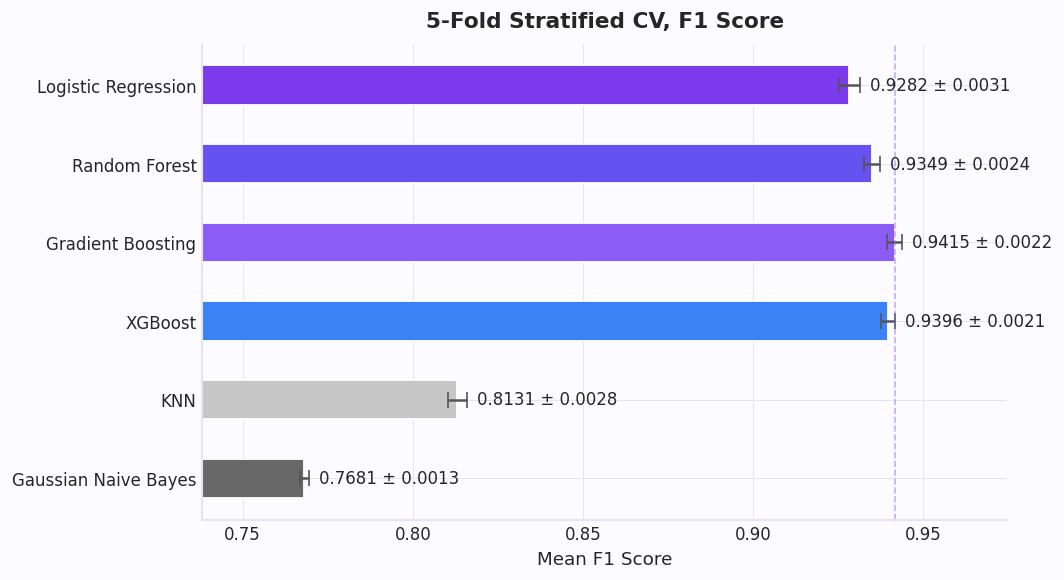

In [13]:
section_title("Baseline and Model Comparison")

dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train, y_train)
y_dummy = dummy.predict(X_test)
print(f"Baseline, majority class, F1: {f1_score(y_test, y_dummy):.4f}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
main_model_names = [
    "Logistic Regression",
    "Random Forest",
    "Gradient Boosting",
    "XGBoost",
]
secondary_model_names = ["KNN", "Gaussian Naive Bayes"]

candidates = {
    "Logistic Regression": lr_pipeline,
    "Random Forest": rf_pipeline,
    "Gradient Boosting": gb_pipeline,
    "XGBoost": xgb_pipeline,
    "KNN": knn_pipeline,
    "Gaussian Naive Bayes": nb_pipeline,
}
display(
    Markdown(
        """
The main model comparison focuses on **Logistic Regression, Random Forest, Gradient Boosting, and XGBoost**.
**KNN** and **Gaussian Naive Bayes** are kept as secondary baselines to show how performance differs across
model families, but model selection should be driven primarily by the stronger tabular classifiers.
"""
    )
)

cv_results: Dict[str, np.ndarray] = {}
print("\nRunning 5-fold stratified cross-validation on training set, scoring by F1.\n")

for name, pipeline in candidates.items():
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
    cv_results[name] = scores
    print(f"{name}: mean F1 = {scores.mean():.4f}  (+/- {scores.std():.4f})")

cv_summary = pd.DataFrame(
    {
        name: {"cv_f1_mean": scores.mean(), "cv_f1_std": scores.std()}
        for name, scores in cv_results.items()
    }
).T

print("\nCross-validation summary:")
display(cv_summary)

fig, ax = plt.subplots(figsize=(9, 5))
means = cv_summary["cv_f1_mean"]
stds = cv_summary["cv_f1_std"]
best = means.idxmax()

bar_colors = []
for i, name in enumerate(means.index):
    if name == best:
        bar_colors.append(ACCENTS[4])
    elif name in main_model_names:
        bar_colors.append(build_palette(len(main_model_names), "blend:#7C3AED,#3B82F6")[main_model_names.index(name)])
    else:
        bar_colors.append(build_palette(len(secondary_model_names), "Greys")[secondary_model_names.index(name)])
bars = ax.barh(
    means.index,
    means,
    xerr=stds,
    color=bar_colors,
    capsize=5,
    edgecolor="white",
    linewidth=1.1,
    height=0.5,
    error_kw={"elinewidth": 1.5, "ecolor": "#555"},
)

for bar, val, std in zip(bars, means, stds):
    ax.text(
        val + std + 0.003,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.4f} ± {std:.4f}",
        va="center",
        fontsize=10,
    )

ax.set_xlim(max(0, means.min() - 0.03), min(1.02, means.max() + stds.max() + 0.03))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.2f}"))
ax.axvline(means.max(), color=ACCENTS[4], linestyle="--", linewidth=1, alpha=0.5)
ax.invert_yaxis()
style_ax(ax, "5-Fold Stratified CV, F1 Score", "Mean F1 Score", "")
plt.tight_layout()
plt.show()

### 3.6 Final Comparison Across Tested Models

This section complements cross-validation by showing held-out test results for
each model considered in the comparison.


Model comparison summary:


,Model,CV F1 Mean,CV F1 Std,Test F1,Test Precision,Test Recall,Test ROC-AUC
2,Gradient Boosting,0.9415,0.0022,0.9409,0.9390,0.9428,0.9757
3,XGBoost,0.9396,0.0021,0.9405,0.9327,0.9485,0.9757
1,Random Forest,0.9349,0.0024,0.9366,0.9419,0.9313,0.9751
0,Logistic Regression,0.9282,0.0031,0.9301,0.9432,0.9173,0.9696
4,KNN,0.8131,0.0028,0.8193,0.7369,0.9223,0.8795
5,Gaussian Naive Bayes,0.7681,0.0013,0.7693,0.6412,0.9613,0.8664



Primary comparison weight should stay on **Logistic Regression, Random Forest, Gradient Boosting, and XGBoost**.
The secondary baselines help sanity-check the problem across simpler model families, but they are not the main
decision drivers for a tabular churn workflow like this one.



Train vs test comparison:


,Model,Train F1,Test F1,F1 Gap
2,Gradient Boosting,0.9527,0.9409,0.0118
3,XGBoost,0.9542,0.9405,0.0137
1,Random Forest,0.9424,0.9366,0.0058
0,Logistic Regression,0.9310,0.9301,0.0009
4,KNN,1.0000,0.8193,0.1807
5,Gaussian Naive Bayes,0.7683,0.7693,-0.0010


This compact view helps check whether performance transfers from training to held-out data. Smaller train-test gaps suggest the model is generalising well rather than fitting only the training sample.


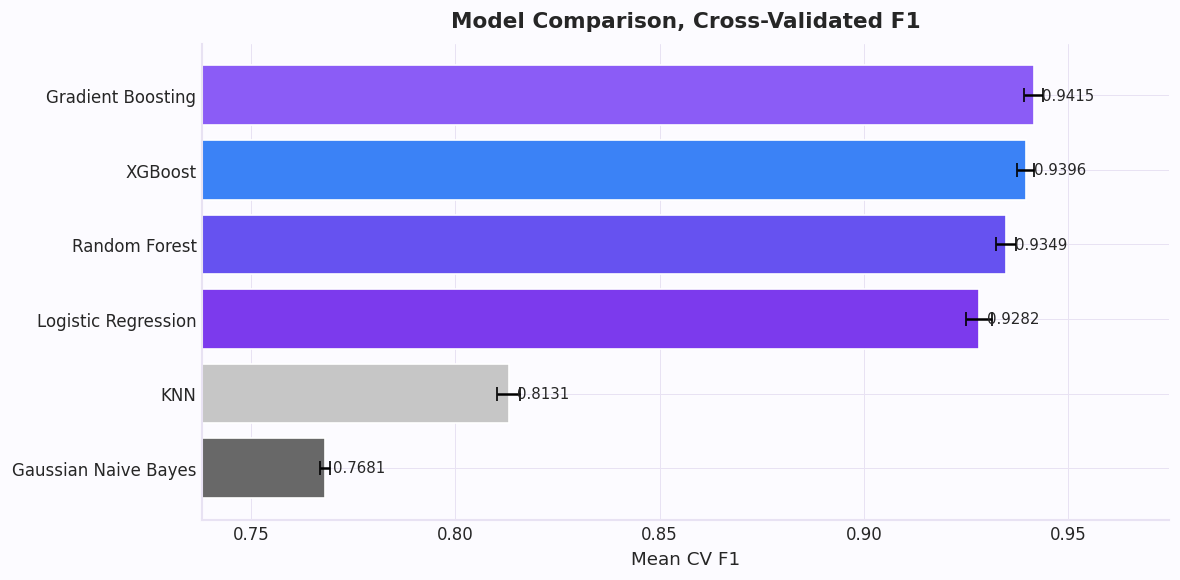

In [14]:
model_test_results = []
for name, pipeline in candidates.items():
    result = evaluate_candidate_on_test(name, pipeline, X_train, X_test, y_train, y_test)
    result["CV F1 Mean"] = cv_summary.loc[name, "cv_f1_mean"]
    result["CV F1 Std"] = cv_summary.loc[name, "cv_f1_std"]
    model_test_results.append(result)

comparison_df = pd.DataFrame(model_test_results)
comparison_df = comparison_df[
    ["Model", "CV F1 Mean", "CV F1 Std", "Test F1", "Test Precision", "Test Recall", "Test ROC-AUC"]
].sort_values("CV F1 Mean", ascending=False)

print("\nModel comparison summary:")
display(
    comparison_df.style.format(
        {
            "CV F1 Mean": "{:.4f}",
            "CV F1 Std": "{:.4f}",
            "Test F1": "{:.4f}",
            "Test Precision": "{:.4f}",
            "Test Recall": "{:.4f}",
            "Test ROC-AUC": "{:.4f}",
        }
    )
)
display(
    Markdown(
        """
Primary comparison weight should stay on **Logistic Regression, Random Forest, Gradient Boosting, and XGBoost**.
The secondary baselines help sanity-check the problem across simpler model families, but they are not the main
decision drivers for a tabular churn workflow like this one.
"""
    )
)

generalisation_rows = []
for name, pipeline in candidates.items():
    pipeline.fit(X_train, y_train)
    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)
    generalisation_rows.append(
        {
            "Model": name,
            "Train F1": f1_score(y_train, y_train_pred),
            "Test F1": f1_score(y_test, y_test_pred),
            "F1 Gap": f1_score(y_train, y_train_pred) - f1_score(y_test, y_test_pred),
        }
    )

generalisation_df = pd.DataFrame(generalisation_rows).sort_values("Test F1", ascending=False)

print("\nTrain vs test comparison:")
display(
    generalisation_df.style.format(
        {
            "Train F1": "{:.4f}",
            "Test F1": "{:.4f}",
            "F1 Gap": "{:.4f}",
        }
    )
)
print(
    "This compact view helps check whether performance transfers from training to held-out data. "
    "Smaller train-test gaps suggest the model is generalising well rather than fitting only the training sample."
)

fig, ax = plt.subplots(figsize=(10, 5))
plot_df = comparison_df.sort_values("CV F1 Mean", ascending=True)

bars = ax.barh(
    plot_df["Model"],
    plot_df["CV F1 Mean"],
    xerr=plot_df["CV F1 Std"],
    color=[
        ACCENTS[4] if name == best else (
            build_palette(len(main_model_names), "blend:#7C3AED,#3B82F6")[main_model_names.index(name)]
            if name in main_model_names
            else build_palette(len(secondary_model_names), "Greys")[secondary_model_names.index(name)]
        )
        for name in plot_df["Model"]
    ],
    edgecolor="white",
    linewidth=1.0,
    capsize=4,
)

for bar, val in zip(bars, plot_df["CV F1 Mean"]):
    ax.text(
        val + 0.002,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.4f}",
        va="center",
        fontsize=9,
    )

style_ax(ax, "Model Comparison, Cross-Validated F1", "Mean CV F1", "")
ax.set_xlim(max(0, plot_df["CV F1 Mean"].min() - 0.03), min(1.00, plot_df["CV F1 Mean"].max() + plot_df["CV F1 Std"].max() + 0.03))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.2f}"))
plt.tight_layout()
plt.show()

### 3.7 Selected Model and Final Held-Out Evaluation


SELECTED MODEL AND FINAL HELD-OUT EVALUATION



### Selected Model Summary
- **Selected model:** Gradient Boosting
- **Cross-validated F1:** 0.9415
- The selected model is now fitted on the full training set for final evaluation.



Gradient Boosting - Final Evaluation

Train Metrics:
  F1:        0.9527
  Precision: 0.9521
  Recall:    0.9532

Test Metrics:
  F1:        0.9409
  Precision: 0.9390
  Recall:    0.9428
  ROC-AUC:   0.9757

Classification Report, Test:
              precision    recall  f1-score   support

    No Churn       0.93      0.93      0.93      3396
       Churn       0.94      0.94      0.94      4003

    accuracy                           0.94      7399
   macro avg       0.94      0.94      0.94      7399
weighted avg       0.94      0.94      0.94      7399



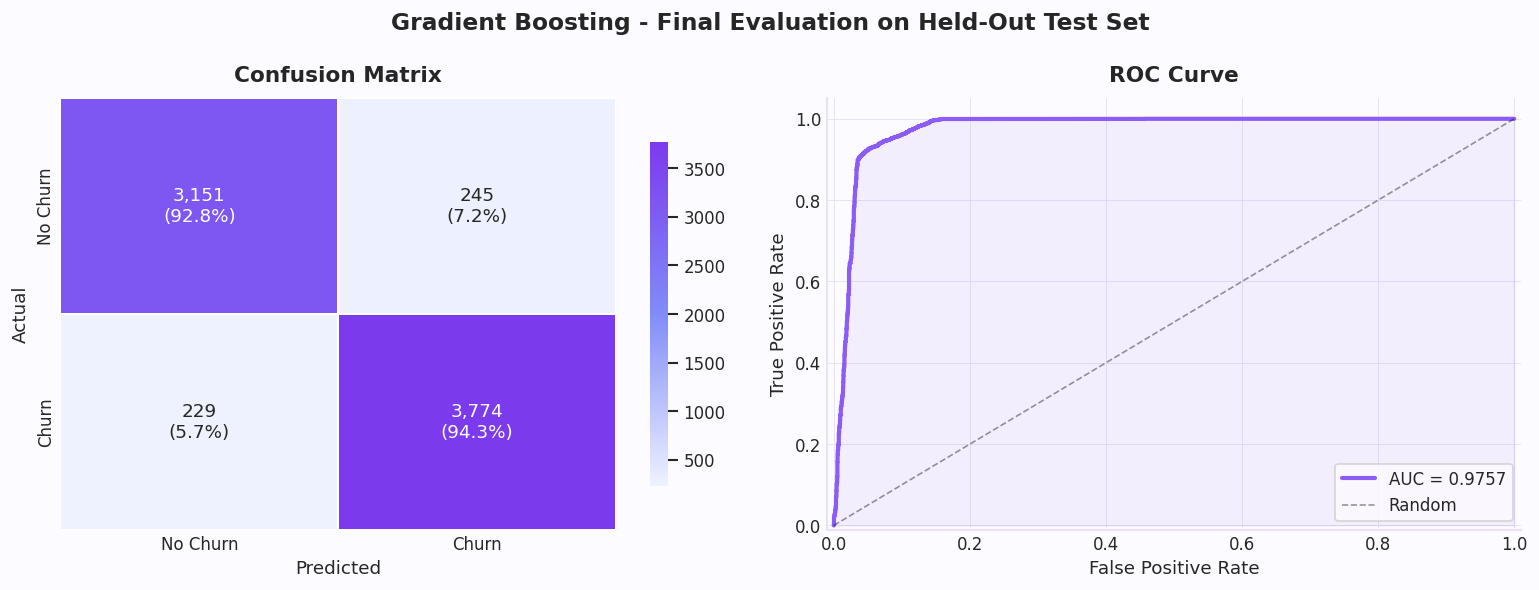

### Threshold Sensitivity

,Threshold,F1,Precision,Recall
0,0.4,0.9396,0.8967,0.9868
1,0.5,0.9409,0.9390,0.9428
2,0.6,0.9401,0.9561,0.9246


In [15]:
section_title("Selected Model and Final Held-Out Evaluation")

best_model_name = cv_summary["cv_f1_mean"].idxmax()
best_pipeline = candidates[best_model_name]

display(
    Markdown(
        f"""
### Selected Model Summary
- **Selected model:** {best_model_name}
- **Cross-validated F1:** {cv_summary.loc[best_model_name, 'cv_f1_mean']:.4f}
- The selected model is now fitted on the full training set for final evaluation.
"""
    )
)

best_pipeline.fit(X_train, y_train)

final_metrics = evaluate_model(best_pipeline, X_train, X_test, y_train, y_test, best_model_name)

y_probs = best_pipeline.predict_proba(X_test)[:, 1]
threshold_rows = []
for threshold in [0.4, 0.5, 0.6]:
    y_custom = (y_probs > threshold).astype(int)
    threshold_rows.append(
        {
            "Threshold": threshold,
            "F1": f1_score(y_test, y_custom),
            "Precision": precision_score(y_test, y_custom),
            "Recall": recall_score(y_test, y_custom),
        }
    )

threshold_df = pd.DataFrame(threshold_rows)
display(Markdown("### Threshold Sensitivity"))
display(
    threshold_df.style.format(
        {
            "Threshold": "{:.1f}",
            "F1": "{:.4f}",
            "Precision": "{:.4f}",
            "Recall": "{:.4f}",
        }
    )
)

### 3.8 Explainability and Advanced Insights


EXPLAINABILITY AND ADVANCED INSIGHTS

Top 15 Feature Importances, Gradient Boosting:
                                feature  importance
                       points_in_wallet    0.542602
      membership_category_No Membership    0.115645
   membership_category_Basic Membership    0.102740
            feedback_sentiment_Negative    0.084953
 membership_category_Premium Membership    0.053000
membership_category_Platinum Membership    0.050824
      wallet_points_group_Medium Points    0.025349
    membership_category_Gold Membership    0.005816
  membership_category_Silver Membership    0.004520
        wallet_points_group_High Points    0.003098
                  avg_transaction_value    0.001539
                         avg_time_spent    0.001356
                   relative_tenure_days    0.001289
                       engagement_score    0.001228
                        value_per_login    0.001204


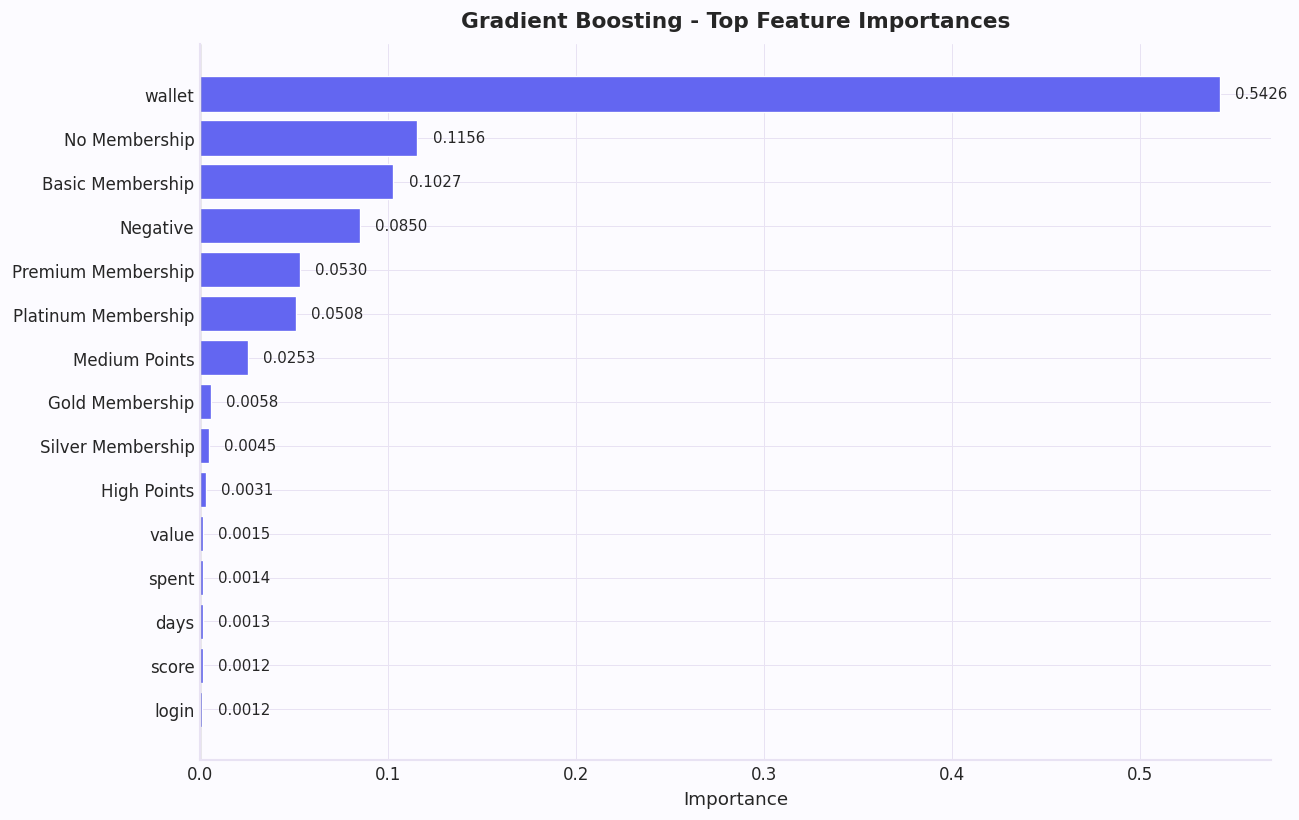

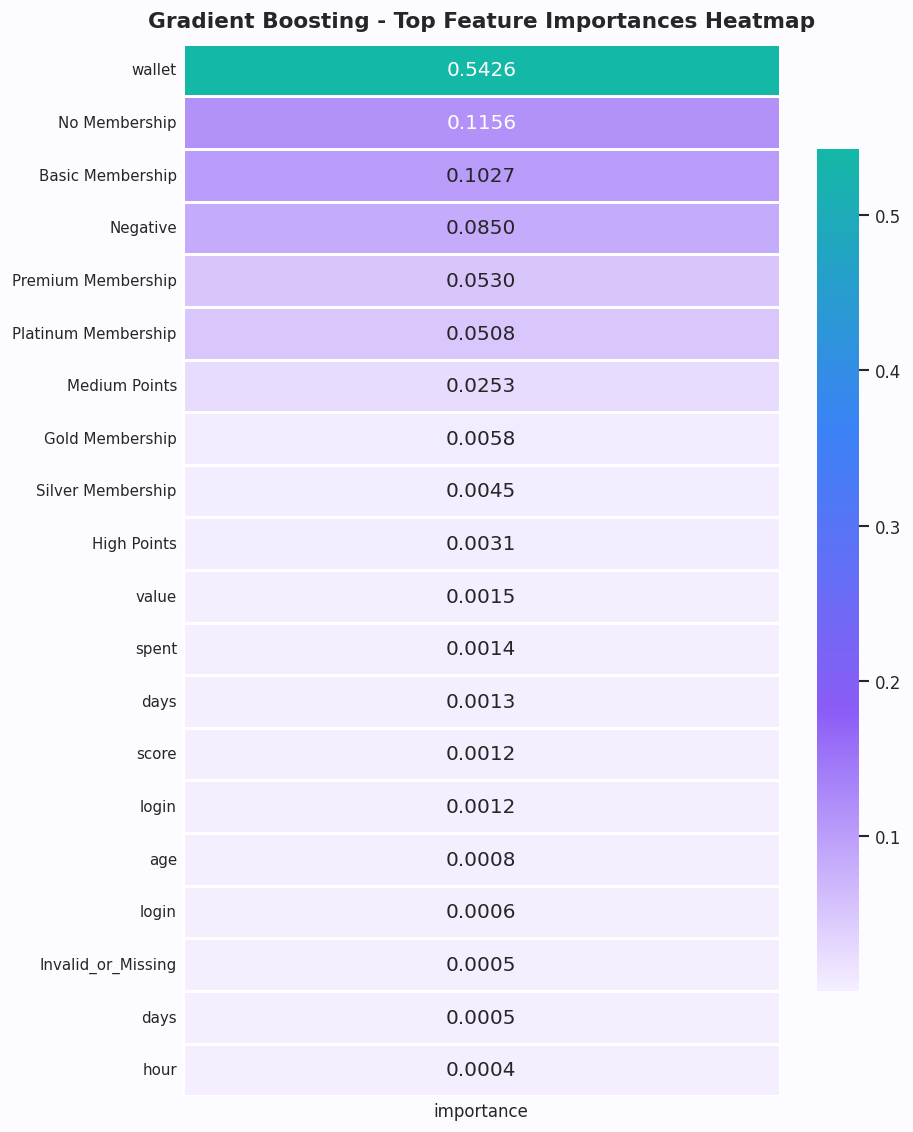


Calculating permutation importance on test set...

Top 15 Permutation Importances:
                                feature  importance
      membership_category_No Membership    0.094432
   membership_category_Basic Membership    0.094418
                       points_in_wallet    0.090918
            feedback_sentiment_Negative    0.068698
membership_category_Platinum Membership    0.058575
 membership_category_Premium Membership    0.058278
  membership_category_Silver Membership    0.002379
        wallet_points_group_High Points    0.002095
                        last_visit_hour    0.001581
    membership_category_Gold Membership    0.001325
                                    age    0.000892
                       engagement_score    0.000878
                         avg_time_spent    0.000838
                   relative_tenure_days    0.000757
      wallet_points_group_Medium Points    0.000541


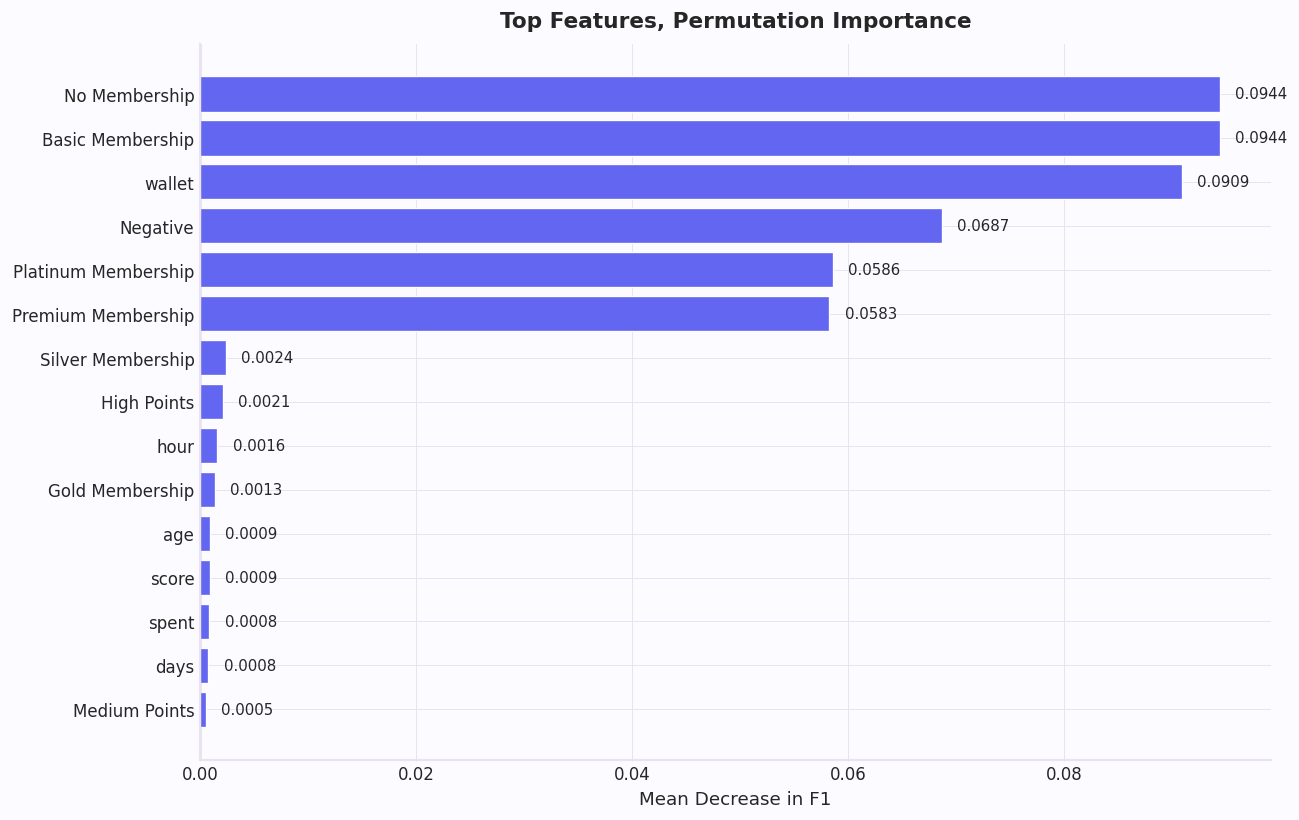

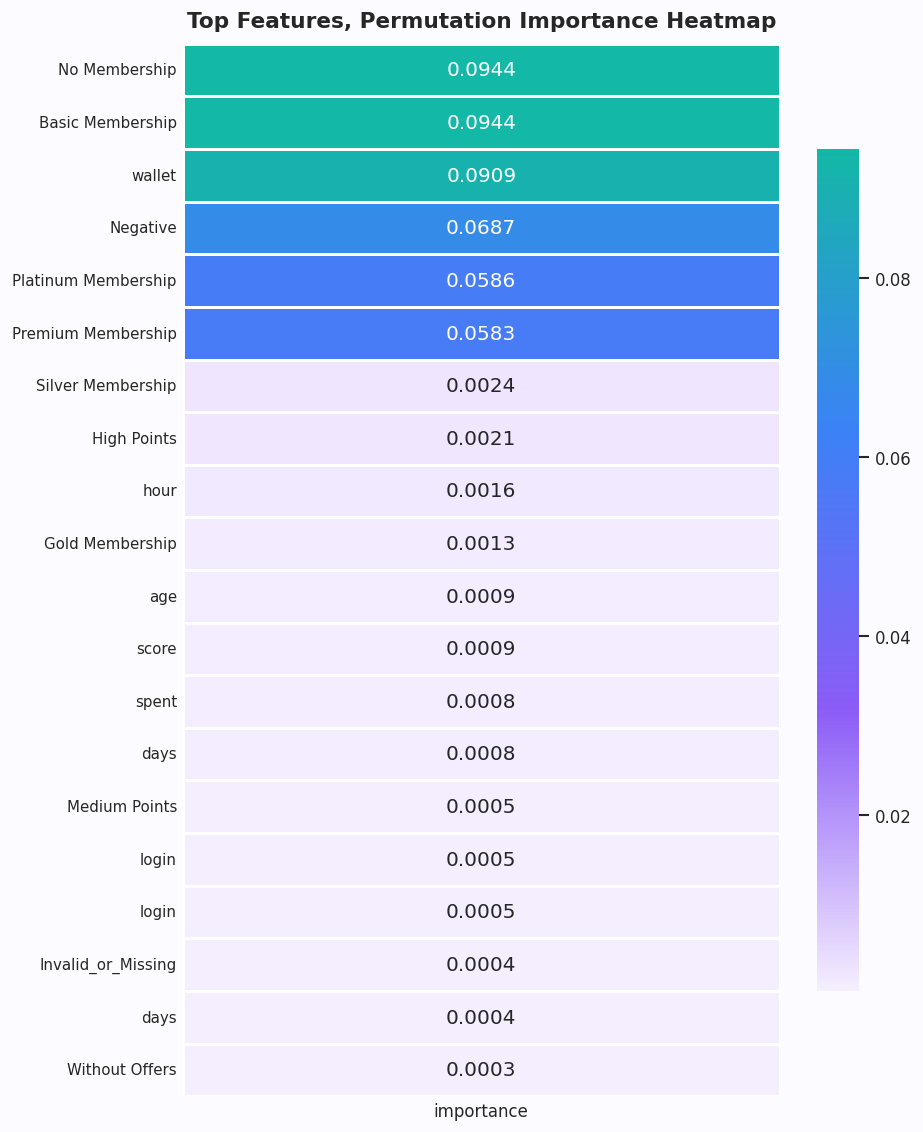


**Interpretation note:** some signals, especially membership-category indicators, wallet-related
features, and negative feedback, appear unusually strong. These are useful predictive markers in this
dataset, but they should be treated as operational signals rather than causal proof.


### Top-Feature Interpretation by Theme

,Theme,Example features
0,Commitment or membership,"membership_category_No Membership, membership_..."
1,Loyalty or value,"points_in_wallet, wallet_points_group_High Points"
2,Customer experience,feedback_sentiment_Negative
3,Engagement,"last_visit_hour, engagement_score"



These themes suggest that churn prediction is being informed by a mix of membership commitment,
customer value or loyalty, customer experience signals, and behavioural engagement. Similar broad
themes appearing in both model-based and permutation importance views make the pattern more credible,
but the interpretation remains predictive rather than causal.


In [16]:
section_title("Explainability and Advanced Insights")

try:
    ohe_feature_names = (
        best_pipeline.named_steps["preprocessor"]
        .named_transformers_["cat"]
        .named_steps["encoder"]
        .get_feature_names_out(nominal_cats)
        .tolist()
    )
    all_feature_names = raw_numeric_features + ohe_feature_names + flag_features
except Exception:
    all_feature_names = list(X.columns)

inner_model = best_pipeline.named_steps["model"]

if hasattr(inner_model, "feature_importances_"):
    feature_importance = pd.DataFrame(
        {
            "feature": all_feature_names,
            "importance": inner_model.feature_importances_,
        }
    ).sort_values("importance", ascending=False)

    print(f"\nTop 15 Feature Importances, {best_model_name}:")
    print(feature_importance.head(15).to_string(index=False))
    plot_importance(feature_importance, "importance", f"{best_model_name} - Top Feature Importances", "Importance")
    plot_importance_heatmap(
        feature_importance,
        "importance",
        f"{best_model_name} - Top Feature Importances Heatmap",
    )

elif hasattr(inner_model, "coef_"):
    feature_importance = pd.DataFrame(
        {
            "feature": all_feature_names,
            "coefficient": inner_model.coef_[0],
        }
    ).sort_values("coefficient", key=abs, ascending=False)

    print(f"\nTop 15 Feature Coefficients, {best_model_name}:")
    print(feature_importance.head(15).to_string(index=False))
    plot_importance(feature_importance, "coefficient", f"{best_model_name} - Top Coefficients", "Coefficient")
    plot_importance_heatmap(
        feature_importance,
        "coefficient",
        f"{best_model_name} - Top Coefficients Heatmap",
        cmap="RdYlBu_r",
    )

print("\nCalculating permutation importance on test set...")
X_test_transformed = best_pipeline.named_steps["preprocessor"].transform(X_test)

perm_imp = permutation_importance(
    inner_model,
    X_test_transformed,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
)

perm_importance_df = pd.DataFrame(
    {
        "feature": all_feature_names,
        "importance": perm_imp.importances_mean,
    }
).sort_values("importance", ascending=False)

print("\nTop 15 Permutation Importances:")
print(perm_importance_df.head(15).to_string(index=False))
plot_importance(perm_importance_df, "importance", "Top Features, Permutation Importance", "Mean Decrease in F1")
plot_importance_heatmap(
    perm_importance_df,
    "importance",
    "Top Features, Permutation Importance Heatmap",
)

display(
    Markdown(
        """
**Interpretation note:** some signals, especially membership-category indicators, wallet-related
features, and negative feedback, appear unusually strong. These are useful predictive markers in this
dataset, but they should be treated as operational signals rather than causal proof.
"""
    )
)

top_features = perm_importance_df.head(12)["feature"].tolist()
feature_themes = {
    "Commitment or membership": [
        feat for feat in top_features if "membership_category" in feat
    ],
    "Loyalty or value": [
        feat
        for feat in top_features
        if any(token in feat for token in ["wallet", "points_in_wallet", "transaction", "value_per_login"])
    ],
    "Customer experience": [
        feat for feat in top_features if any(token in feat for token in ["feedback", "complaint"])
    ],
    "Engagement": [
        feat
        for feat in top_features
        if any(token in feat for token in ["login", "time_spent", "engagement", "last_visit_hour"])
    ],
}

theme_rows = [
    {"Theme": theme, "Example features": ", ".join(features[:3])}
    for theme, features in feature_themes.items()
    if features
]
display(Markdown("### Top-Feature Interpretation by Theme"))
display(pd.DataFrame(theme_rows))
display(
    Markdown(
        """
These themes suggest that churn prediction is being informed by a mix of membership commitment,
customer value or loyalty, customer experience signals, and behavioural engagement. Similar broad
themes appearing in both model-based and permutation importance views make the pattern more credible,
but the interpretation remains predictive rather than causal.
"""
    )
)

## 4. Business Recommendations and Production Considerations

In [17]:
section_title("Business Recommendations and Production Considerations")

top_features = perm_importance_df.head(10)["feature"].tolist()
display(
    Markdown(
        f"""
### 1. Key Business Insights
- Strong predictive signals include: **{', '.join(top_features[:5])}**
- These should be treated as **prioritisation signals**, not direct causes of churn.

### 2. Recommended Action Areas
- Review negative feedback and unresolved complaint patterns closely.
- Prioritise inactive and highly inactive customers for re-engagement.
- Investigate whether lower value or lower wallet-point customers need targeted retention treatment.
- Review membership segments with higher predicted churn risk.

### 3. Field Testing Approach
- Run an A/B test using model-driven interventions against a control group.
- Compare retention uplift against operational cost.
- Validate score quality on future data before broader rollout.

### 4. Productionisation Considerations
- Confirm all model features are available at scoring time in real workflows.
- Automate refresh of input data and scoring outputs.
- Integrate outputs into CRM or customer operations processes.
- Monitor drift, missingness, and score performance over time.
"""
    )
)

business_usefulness_df = pd.DataFrame(
    [
        {
            "Metric": "Recall",
            "Value": final_metrics["recall"],
            "Interpretation": "Share of churners identified",
        },
        {
            "Metric": "Precision",
            "Value": final_metrics["precision"],
            "Interpretation": "Share of flagged customers who are true churners",
        },
    ]
)

display(Markdown("### 5. Expected Business Usefulness"))
display(
    business_usefulness_df.style.format({"Value": "{:.1%}"})
)
display(
    Markdown(
        """
- These outputs can support prioritised outreach rather than relying only on anecdotal judgement.
- Similar broad predictive patterns across linear and tree-based models suggest the signal is not dependent on one algorithm alone.
"""
    )
)


BUSINESS RECOMMENDATIONS AND PRODUCTION CONSIDERATIONS



### 1. Key Business Insights
- Strong predictive signals include: **membership_category_No Membership, membership_category_Basic Membership, points_in_wallet, feedback_sentiment_Negative, membership_category_Platinum Membership**
- These should be treated as **prioritisation signals**, not direct causes of churn.

### 2. Recommended Action Areas
- Review negative feedback and unresolved complaint patterns closely.
- Prioritise inactive and highly inactive customers for re-engagement.
- Investigate whether lower value or lower wallet-point customers need targeted retention treatment.
- Review membership segments with higher predicted churn risk.

### 3. Field Testing Approach
- Run an A/B test using model-driven interventions against a control group.
- Compare retention uplift against operational cost.
- Validate score quality on future data before broader rollout.

### 4. Productionisation Considerations
- Confirm all model features are available at scoring time in real workflows.
- Automate refresh of input data and scoring outputs.
- Integrate outputs into CRM or customer operations processes.
- Monitor drift, missingness, and score performance over time.


### 5. Expected Business Usefulness

,Metric,Value,Interpretation
0,Recall,94.3%,Share of churners identified
1,Precision,93.9%,Share of flagged customers who are true churners



- These outputs can support prioritised outreach rather than relying only on anecdotal judgement.
- Similar broad predictive patterns across linear and tree-based models suggest the signal is not dependent on one algorithm alone.


## 5. Limitations and Important Caveats

In [18]:
display(
    Markdown(
        """
- The supplied target is used as given and treated as binary classification.
- The working dataset supports a 0/1 target.
- No true churn timestamp is available, so this is not a full event-time churn model.
- `relative_tenure_days` is relative to the latest joining date in the dataset, not true production tenure at scoring time.
- Some fields, especially complaint and feedback related variables, may be close to the outcome timing.
- Feature importance is predictive, not causal.
- Out-of-time validation remains necessary before production deployment.
"""
    )
)


- The supplied target is used as given and treated as binary classification.
- The working dataset supports a 0/1 target.
- No true churn timestamp is available, so this is not a full event-time churn model.
- `relative_tenure_days` is relative to the latest joining date in the dataset, not true production tenure at scoring time.
- Some fields, especially complaint and feedback related variables, may be close to the outcome timing.
- Feature importance is predictive, not causal.
- Out-of-time validation remains necessary before production deployment.


## 6. Final Summary

In [19]:
section_title("Final Summary")

metric_block(
    "Model Performance Summary",
    {
        "Selected model": best_model_name,
        "CV F1, mean": cv_summary.loc[best_model_name, "cv_f1_mean"],
        "Test F1": final_metrics["f1"],
        "Test Recall": final_metrics["recall"],
        "Test ROC-AUC": final_metrics["roc_auc"],
    },
)

print(
    "\nThe final workflow combines exploratory analysis, feature engineering, predictive modelling, "
    "model comparison, and explainability. It is intended as a practical and interpretable starting point "
    "for proactive retention analysis, while still requiring future-data validation and production checks."
)


FINAL SUMMARY

Model Performance Summary
-------------------------
Selected model              : Gradient Boosting
CV F1, mean                 : 0.9415
Test F1                     : 0.9409
Test Recall                 : 0.9428
Test ROC-AUC                : 0.9757

The final workflow combines exploratory analysis, feature engineering, predictive modelling, model comparison, and explainability. It is intended as a practical and interpretable starting point for proactive retention analysis, while still requiring future-data validation and production checks.
